# File 1 — Setup & Data Loading

Merged from `gdsc_preprocessing.ipynb`. Run cells below in order.

# 💊 Drug Sensitivity Prediction — GDSC1 & GDSC2
## Section 1: Environment Setup & Data Preprocessing

This notebook covers:
- Installing required packages (`torch_geometric`, `rdkit`)
- All library imports
- Reproducibility seeding
- Uploading and loading GDSC1/GDSC2 CSVs
- Cleaning, concatenating, encoding, and imputing the data


---
## 📦 1. Install Dependencies
Install `torch_geometric` for graph neural networks and `rdkit-pypi` for molecular feature processing.

In [3]:
# Install dependencies safely for current Colab Python versions

import sys
import subprocess

packages = [
    "torch-geometric",
    "rdkit"
]

for pkg in packages:
    print(f"Installing {pkg} ...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        pkg
    ])

# Quick RDKit test
from rdkit import Chem
test_mol = Chem.MolFromSmiles("CCO")
assert test_mol is not None, "RDKit installation failed."

print("✅ Dependencies installed successfully.")
print("✅ RDKit test passed.")

Installing torch-geometric ...
Installing rdkit ...
✅ Dependencies installed successfully.
✅ RDKit test passed.


---
## 📚 2. Imports
All standard and third-party imports needed for data processing, modelling, and visualisation.

In [4]:
# ── Standard library ────────────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

# ── Numerical & data ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

# ── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── PyTorch Geometric ───────────────────────────────────────────────────────
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

# ── RDKit ───────────────────────────────────────────────────────────────────
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

print(f"PyTorch      : {torch.__version__}")
print(f"Torch Geom.  : {torch_geometric.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device   : {torch.cuda.get_device_name(0)}")

PyTorch      : 2.10.0+cu128
Torch Geom.  : 2.7.0
CUDA available: True
GPU Device   : Tesla T4


---
## 🌱 3. Reproducibility — `set_seed`
Fix all random seeds so results are fully reproducible across runs.

In [5]:
def set_seed(seed: int = 42) -> None:
    """Fix seeds for Python, NumPy, and PyTorch (CPU + GPU)."""
    random.seed(seed)                          # Python built-in
    np.random.seed(seed)                       # NumPy
    torch.manual_seed(seed)                    # PyTorch CPU
    torch.cuda.manual_seed(seed)               # PyTorch single-GPU
    torch.cuda.manual_seed_all(seed)           # PyTorch multi-GPU
    os.environ['PYTHONHASHSEED'] = str(seed)   # Python hash randomisation
    # Ensure deterministic CUDA ops (may slightly reduce performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
print("✅ Seed set to 42.")

✅ Seed set to 42.


---
## 📂 4. Upload GDSC CSV Files
Use Colab's built-in file upload widget to upload `GDSC1.csv` and `GDSC2.csv` from your local machine.

In [7]:
from google.colab import files

print("📤 Please upload GDSC1.csv and GDSC2.csv when prompted...")
uploaded = files.upload()   # Opens a file-picker dialog

# Confirm which files were received
for fname in uploaded.keys():
    print(f"  ✔ Received: {fname}  ({len(uploaded[fname]):,} bytes)")

📤 Please upload GDSC1.csv and GDSC2.csv when prompted...


Saving GDSC1.csv to GDSC1.csv
Saving GDSC2.csv to GDSC2.csv
  ✔ Received: GDSC1.csv  (96,474,068 bytes)
  ✔ Received: GDSC2.csv  (42,661,946 bytes)


---
## 🗂️ 5. Load, Clean & Concatenate GDSC1 + GDSC2

Steps:
1. Read both CSVs into separate DataFrames.
2. Add a `source` column so we can trace which dataset each row came from.
3. Drop the `log_max_conc_tested` and `log_max_conc_tested_2` columns (not used as features).
4. Concatenate into a single DataFrame `df` and reset the index.

In [8]:
# ── Load raw CSVs ────────────────────────────────────────────────────────────
gdsc1 = pd.read_csv('GDSC1.csv')
gdsc2 = pd.read_csv('GDSC2.csv')

print(f"GDSC1 shape (raw): {gdsc1.shape}")
print(f"GDSC2 shape (raw): {gdsc2.shape}")

# ── Tag each row with its source dataset ─────────────────────────────────────
gdsc1['source'] = 'GDSC1'
gdsc2['source'] = 'GDSC2'

# ── Drop log_max_conc_tested columns ─────────────────────────────────────────
# These columns are experimental design metadata, not predictive features.
cols_to_drop = ['log_max_conc_tested', 'log_max_conc_tested_2']

gdsc1.drop(columns=[c for c in cols_to_drop if c in gdsc1.columns], inplace=True)
gdsc2.drop(columns=[c for c in cols_to_drop if c in gdsc2.columns], inplace=True)

# ── Concatenate into a single DataFrame ──────────────────────────────────────
df = pd.concat([gdsc1, gdsc2], ignore_index=True)

print(f"\nCombined df shape : {df.shape}")
print(f"Columns           : {list(df.columns)}")
df.head()

GDSC1 shape (raw): (269547, 22)
GDSC2 shape (raw): (200920, 22)

Combined df shape : (470467, 21)
Columns           : ['Drug name', 'Drug ID', 'Drug target', 'Target Pathway', 'Feature Name', 'n_feature_pos', 'n_feature_neg', 'ic50_effect_size', 'log_ic50_mean_pos', 'log_ic50_mean_neg', 'feature_ic50_t_pval', 'feature_delta_mean_ic50', 'feature_pos_ic50_var', 'feature_neg_ic50_var', 'feature_pval', 'tissue_pval', 'msi_pval', 'fdr', 'Tissue Type', 'Screening Set', 'source']


,Drug name,Drug ID,Drug target,Target Pathway,Feature Name,n_feature_pos,n_feature_neg,ic50_effect_size,log_ic50_mean_pos,log_ic50_mean_neg,...,feature_delta_mean_ic50,feature_pos_ic50_var,feature_neg_ic50_var,feature_pval,tissue_pval,msi_pval,fdr,Tissue Type,Screening Set,source
0,Erlotinib,1,EGFR,EGFR signaling,ABCB1_mut,7,385,0.412899,2.970994,2.510056,...,0.460938,0.701908,1.121606,0.998333,8.170801e-10,0.112903,95.164834,PANCANCER,GDSC1,GDSC1
1,Erlotinib,1,EGFR,EGFR signaling,ABL2_mut,3,389,0.397481,2.959013,2.514889,...,0.444125,0.145293,1.120175,0.812046,8.131018e-10,0.112876,94.187019,PANCANCER,GDSC1,GDSC1
2,Erlotinib,1,EGFR,EGFR signaling,ACACA_mut,3,389,0.275123,2.823438,2.515934,...,0.307504,0.077976,1.120561,0.897537,8.159116e-10,0.112895,94.352801,PANCANCER,GDSC1,GDSC1
3,Erlotinib,1,EGFR,EGFR signaling,ACVR2A_mut,7,385,0.118331,2.648205,2.515925,...,0.132280,1.045146,1.118982,0.521762,7.886244e-10,0.112701,94.187019,PANCANCER,GDSC1,GDSC1
4,Erlotinib,1,EGFR,EGFR signaling,AFF4_mut,4,388,0.009431,2.507851,2.518395,...,-0.010544,0.302481,1.122030,0.457418,7.790175e-10,0.112631,94.187019,PANCANCER,GDSC1,GDSC1


---
## 🏷️ 6. Label Encoding of Categorical Columns

Encode four categorical columns into integer IDs. Each fitted `LabelEncoder` is stored in `label_encoders` so it can be reused for decoding or transforming unseen data later.

In [9]:
# Columns that require label encoding
CATEGORICAL_COLS = ['Drug name', 'Feature Name', 'Tissue Type', 'Screening Set']

# Dictionary to store fitted encoders — keyed by column name
label_encoders: dict[str, LabelEncoder] = {}

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))   # astype(str) handles any stray NaNs
    label_encoders[col] = le                           # save encoder for later inverse_transform
    print(f"  {col:<20} → {len(le.classes_):>5} unique classes")

print(f"\n✅ Label encoding complete. Encoders stored in `label_encoders`.")
print(f"   Keys: {list(label_encoders.keys())}")

  Drug name            →   544 unique classes
  Feature Name         →   692 unique classes
  Tissue Type          →     1 unique classes
  Screening Set        →     2 unique classes

✅ Label encoding complete. Encoders stored in `label_encoders`.
   Keys: ['Drug name', 'Feature Name', 'Tissue Type', 'Screening Set']


---
## 🩹 7. Impute Missing Values

Fill `NaN`s in numeric feature columns with the **column mean**. Categorical columns are already encoded as integers and should have no missing values at this stage.

In [10]:
# Numeric feature columns to impute
FEATURE_COLS = [
    'n_feature_pos',
    'n_feature_neg',
    'log_ic50_mean_pos',
    'log_ic50_mean_neg',
    'feature_pos_ic50_var',
    'feature_neg_ic50_var',
    'feature_delta_mean_ic50',
    'feature_ic50_t_pval',
    'feature_pval',
    'tissue_pval',
    'msi_pval',
    'ic50_effect_size',
]

# Check missing counts before imputation
missing_before = df[FEATURE_COLS].isnull().sum()
print("Missing values BEFORE imputation:")
print(missing_before[missing_before > 0].to_string() or "  None")

# Fill NaN with column mean
col_means = df[FEATURE_COLS].mean()          # compute means on non-null values
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(col_means)

# Verify no NaNs remain
missing_after = df[FEATURE_COLS].isnull().sum().sum()
print(f"\nMissing values AFTER imputation : {missing_after}")
print(f"✅ Imputation complete. df ready for modelling — shape: {df.shape}")

Missing values BEFORE imputation:
Series([], )

Missing values AFTER imputation : 0
✅ Imputation complete. df ready for modelling — shape: (470467, 21)


---
## 🔍 Quick Sanity Check
Peek at the final cleaned DataFrame and its dtypes.

In [11]:
print("DataFrame info:")
print(df.dtypes)
print(f"\nShape : {df.shape}")
df.head()

DataFrame info:
Drug name                    int64
Drug ID                      int64
Drug target                 object
Target Pathway              object
Feature Name                 int64
n_feature_pos                int64
n_feature_neg                int64
ic50_effect_size           float64
log_ic50_mean_pos          float64
log_ic50_mean_neg          float64
feature_ic50_t_pval        float64
feature_delta_mean_ic50    float64
feature_pos_ic50_var       float64
feature_neg_ic50_var       float64
feature_pval               float64
tissue_pval                float64
msi_pval                   float64
fdr                        float64
Tissue Type                  int64
Screening Set                int64
source                      object
dtype: object

Shape : (470467, 21)


,Drug name,Drug ID,Drug target,Target Pathway,Feature Name,n_feature_pos,n_feature_neg,ic50_effect_size,log_ic50_mean_pos,log_ic50_mean_neg,...,feature_delta_mean_ic50,feature_pos_ic50_var,feature_neg_ic50_var,feature_pval,tissue_pval,msi_pval,fdr,Tissue Type,Screening Set,source
0,183,1,EGFR,EGFR signaling,0,7,385,0.412899,2.970994,2.510056,...,0.460938,0.701908,1.121606,0.998333,8.170801e-10,0.112903,95.164834,0,0,GDSC1
1,183,1,EGFR,EGFR signaling,1,3,389,0.397481,2.959013,2.514889,...,0.444125,0.145293,1.120175,0.812046,8.131018e-10,0.112876,94.187019,0,0,GDSC1
2,183,1,EGFR,EGFR signaling,2,3,389,0.275123,2.823438,2.515934,...,0.307504,0.077976,1.120561,0.897537,8.159116e-10,0.112895,94.352801,0,0,GDSC1
3,183,1,EGFR,EGFR signaling,4,7,385,0.118331,2.648205,2.515925,...,0.132280,1.045146,1.118982,0.521762,7.886244e-10,0.112701,94.187019,0,0,GDSC1
4,183,1,EGFR,EGFR signaling,5,4,388,0.009431,2.507851,2.518395,...,-0.010544,0.302481,1.122030,0.457418,7.790175e-10,0.112631,94.187019,0,0,GDSC1


# File 2 — Scaffold-Blind Split

Merged from `gdsc_scaffold_split.ipynb`. Run cells below in order.

# 💊 Drug Sensitivity Prediction — GDSC1 & GDSC2
## Section 2: Scaffold-Blind Train / Test Split & PyG Data Construction

**Why scaffold-blind splitting?**  
A standard random split lets structurally similar drugs appear in both train and test, causing the model to memorise scaffolds rather than learn generalisable structure–activity relationships.  
By splitting at the **Murcko scaffold level** we ensure no chemical scaffold seen during training leaks into the test set — giving a more realistic estimate of generalisation to novel compounds.

This section covers:
1. SMILES dictionary for 15 known GDSC drugs
2. Murcko scaffold extraction via RDKit
3. 80/20 scaffold-level split → `train_drugs` / `test_drugs`
4. DataFrame filtering into `df_train` / `df_test`
5. `StandardScaler` fit on train, transform both splits
6. PyTorch Geometric `Data` object construction
7. Move both `data_train` / `data_test` to GPU/CPU device


---
## 🧪 1. GDSC Drug SMILES Dictionary

SMILES strings for 15 well-characterised GDSC drugs.  
These are canonical SMILES sourced from PubChem / ChEMBL.

In [12]:
# ── SMILES for 15 GDSC drugs ─────────────────────────────────────────────────
# Keys must exactly match the drug names used in the GDSC CSVs.
GDSC_SMILES: dict[str, str] = {
    # EGFR inhibitors
    'Erlotinib'     : 'COCCOC1=CC2=C(C=C1OCCOC)C(=NC=N2)NC3=CC=CC(=C3)C#C',
    'Gefitinib'     : 'COC1=CC2=C(C=C1OCCCN3CCOCC3)C(=NC=N2)NC4=CC(=C(C=C4)F)Cl',
    'Lapatinib'     : 'CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1',
    'Afatinib'      : 'CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC1CCOC1',

    # BCR-ABL / multi-kinase inhibitors
    'Imatinib'      : 'Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1',
    'Dasatinib'     : 'Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCO)CC2)n1',
    'Nilotinib'     : 'Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c2)cc1C(F)(F)F',

    # VEGFR / multi-kinase inhibitors
    'Sorafenib'     : 'CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1',
    'Sunitinib'     : 'CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C',

    # BRAF inhibitor
    'Vemurafenib'   : 'CCCS(=O)(=O)Nc1ccc(F)c(C(=O)c2c[nH]c3ncc(-c4ccc(Cl)cc4)cc23)c1F',

    # MEK inhibitor
    'Selumetinib'   : 'Cc1cc2c(Nc3ccc(I)c(F)c3F)[n]c(=O)[n]c2c(Cl)c1',

    # Microtubule stabiliser
    'Paclitaxel'    : 'CC1=C2C(C(=O)C3(C(CC4C(C3C(C(=C2OC(=O)C5=CC=CC=C5)C)OC(=O)C)(CO4)OC(=O)C)O)C)OC(=O)C6=CC=CC=C6',

    # Topoisomerase I inhibitor
    'Camptothecin'  : 'CCC1(O)C(=O)OCc2c1cc1ccc3ccnc4ccc(c2)c1c34',

    # mTOR inhibitor
    'Temsirolimus'  : 'C[C@@H]1CC[C@H]2C[C@@H](/C(=C/[C@@H]3CC(=O)[C@H](C/C(=C/[C@H](C(=O)[C@@H](OC(=O)[C@@H]([C@@H](C[C@@H]([C@@H]1OC)O)OC)CC(=O)O2)C)C)C)C3=O)O)OC',

    # HDAC inhibitor
    'Vorinostat'    : 'O=C(CCCCCCC(=O)Nc1ccccc1)NO',
}

print(f"✅ GDSC_SMILES loaded: {len(GDSC_SMILES)} drugs")
for name, smi in GDSC_SMILES.items():
    print(f"  {name:<18} | {smi[:60]}..." if len(smi) > 60 else f"  {name:<18} | {smi}")

✅ GDSC_SMILES loaded: 15 drugs
  Erlotinib          | COCCOC1=CC2=C(C=C1OCCOC)C(=NC=N2)NC3=CC=CC(=C3)C#C
  Gefitinib          | COC1=CC2=C(C=C1OCCCN3CCOCC3)C(=NC=N2)NC4=CC(=C(C=C4)F)Cl
  Lapatinib          | CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4...
  Afatinib           | CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC1CCOC1
  Imatinib           | Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1
  Dasatinib          | Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCO)CC2)n1
  Nilotinib          | Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c2)cc1C(F)(F)F
  Sorafenib          | CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1
  Sunitinib          | CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(F)cc32)c1C
  Vemurafenib        | CCCS(=O)(=O)Nc1ccc(F)c(C(=O)c2c[nH]c3ncc(-c4ccc(Cl)cc4)cc23)...
  Selumetinib        | Cc1cc2c(Nc3ccc(I)c(F)c3F)[n]c(=O)[n]c2c(Cl)c1
  Paclitaxel         | CC1=C2C(C(=O)C3(C(CC4C(C3C(C(=C2OC(=O)C5=CC=CC=C5)C)OC(=O)C)...


---
## 🔬 2. Murcko Scaffold Extraction

The **Bemis-Murcko scaffold** strips all side chains from a molecule, retaining only the ring systems and the linkers between them.  
Two drugs with the same scaffold are considered chemically similar — we must keep them on the same side of the split.

In [13]:
from rdkit.Chem.Scaffolds import MurckoScaffold


def get_scaffold(smiles: str, generic: bool = False) -> str:
    """
    Return the Murcko scaffold SMILES for a given molecule SMILES.

    Parameters
    ----------
    smiles  : SMILES string of the molecule.
    generic : If True, replace all atoms with carbons and all bonds with
              single bonds (framework scaffold). Default False keeps
              atom identity (Murcko scaffold).

    Returns
    -------
    Canonical scaffold SMILES string, or empty string on parse failure.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ''   # unparseable SMILES → treat as unique scaffold

    if generic:
        scaffold = MurckoScaffold.MakeScaffoldGeneric(
            MurckoScaffold.GetScaffoldForMol(mol)
        )
    else:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)

    return Chem.MolToSmiles(scaffold) if scaffold else ''


# ── Compute scaffold for every drug in the dictionary ────────────────────────
drug_scaffolds: dict[str, str] = {
    name: get_scaffold(smi) for name, smi in GDSC_SMILES.items()
}

print("Drug → Murcko scaffold:")
for name, scaf in drug_scaffolds.items():
    print(f"  {name:<18} | {scaf}")

Drug → Murcko scaffold:
  Erlotinib          | c1ccc(Nc2ncnc3ccccc23)cc1
  Gefitinib          | c1ccc(Nc2ncnc3ccc(OCCCN4CCOCC4)cc23)cc1
  Lapatinib          | c1ccc(COc2ccc(Nc3ncnc4ccc(-c5ccco5)cc34)cc2)cc1
  Afatinib           | c1ccc(Nc2ncnc3cc(OC4CCOC4)ccc23)cc1
  Imatinib           | O=C(Nc1cccc(Nc2nccc(-c3cccnc3)n2)c1)c1ccc(CN2CCNCC2)cc1
  Dasatinib          | O=C(Nc1ccccc1)c1cnc(Nc2cc(N3CCNCC3)ncn2)s1
  Nilotinib          | O=C(Nc1cccc(Nc2nccc(-c3cccnc3)n2)c1)c1ccccc1
  Sorafenib          | O=C(Nc1ccccc1)Nc1ccc(Oc2ccncc2)cc1
  Sunitinib          | O=C1Nc2ccccc2/C1=C/c1ccc[nH]1
  Vemurafenib        | O=C(c1ccccc1)c1c[nH]c2ncc(-c3ccccc3)cc12
  Selumetinib        | 
  Paclitaxel         | 
  Camptothecin       | 
  Temsirolimus       | O=C1C/C=C/C[C@H]2C(=O)C[C@@H](/C=C/CC[C@@H]3CCCCCCC[C@@H](CC(=O)O3)C(=O)OC1)C2=O
  Vorinostat         | c1ccccc1


[17:38:32] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 15 18 19 20 22
[17:38:32] SMILES Parse Error: unclosed ring for input: 'CC1=C2C(C(=O)C3(C(CC4C(C3C(C(=C2OC(=O)C5=CC=CC=C5)C)OC(=O)C)(CO4)OC(=O)C)O)C)OC(=O)C6=CC=CC=C6'
[17:38:32] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24


---
## 🗺️ 3. Map Every Drug ID to Its Scaffold

Using `label_encoders['Drug name']` we convert drug names → integer IDs (as stored in `df`), then build a lookup table `drug_id_to_scaffold`.

In [14]:
# ── Retrieve the fitted LabelEncoder for drug names ───────────────────────────
drug_le = label_encoders['Drug name']   # fitted in Section 1

# ── Build drug_name → encoded_id lookup ──────────────────────────────────────
# drug_le.classes_ is an array of original string names in label order
name_to_id: dict[str, int] = {
    name: idx for idx, name in enumerate(drug_le.classes_)
}

# ── Map encoded drug ID → scaffold SMILES ────────────────────────────────────
# For drugs not in GDSC_SMILES, assign a unique placeholder scaffold
# so they are treated as structurally distinct (won't contaminate splits).
drug_id_to_scaffold: dict[int, str] = {}

for drug_name, encoded_id in name_to_id.items():
    if drug_name in drug_scaffolds and drug_scaffolds[drug_name]:
        drug_id_to_scaffold[encoded_id] = drug_scaffolds[drug_name]
    else:
        # Unique placeholder — drug won't share scaffold with any other
        drug_id_to_scaffold[encoded_id] = f'__unknown_{encoded_id}__'

# ── Group drug IDs by scaffold ────────────────────────────────────────────────
from collections import defaultdict

scaffold_to_drug_ids: dict[str, list[int]] = defaultdict(list)
for drug_id, scaffold in drug_id_to_scaffold.items():
    scaffold_to_drug_ids[scaffold].append(drug_id)

num_drugs      = df['Drug name'].nunique()
num_scaffolds  = len(scaffold_to_drug_ids)

print(f"Total unique drug IDs  : {num_drugs}")
print(f"Total unique scaffolds : {num_scaffolds}")
print(f"\nSample scaffold groups (first 5):")
for sc, ids in list(scaffold_to_drug_ids.items())[:5]:
    label = sc if len(sc) < 60 else sc[:57] + '...'
    print(f"  [{label}]  →  drug IDs: {ids}")

Total unique drug IDs  : 544
Total unique scaffolds : 544

Sample scaffold groups (first 5):
  [__unknown_0__]  →  drug IDs: [0]
  [__unknown_1__]  →  drug IDs: [1]
  [__unknown_2__]  →  drug IDs: [2]
  [__unknown_3__]  →  drug IDs: [3]
  [__unknown_4__]  →  drug IDs: [4]


---
## ✂️ 4. 80 / 20 Scaffold-Level Split

Scaffolds (not individual drugs) are randomly shuffled and split 80/20.  
All drug IDs belonging to the same scaffold land on the **same side** of the split — preventing leakage.

In [15]:
from sklearn.model_selection import train_test_split

# ── Collect all unique scaffolds (deterministic order for seeding) ────────────
all_scaffolds = list(scaffold_to_drug_ids.keys())

# 80/20 split at scaffold level (random_state ensures reproducibility)
train_scaffolds, test_scaffolds = train_test_split(
    all_scaffolds,
    test_size=0.20,
    random_state=42,
    shuffle=True,
)

# ── Expand scaffold sets → drug ID sets ──────────────────────────────────────
train_drugs: set[int] = {
    drug_id
    for sc in train_scaffolds
    for drug_id in scaffold_to_drug_ids[sc]
}
test_drugs: set[int] = {
    drug_id
    for sc in test_scaffolds
    for drug_id in scaffold_to_drug_ids[sc]
}

# ── Verify zero overlap ───────────────────────────────────────────────────────
scaffold_overlap = set(train_scaffolds) & set(test_scaffolds)
drug_overlap     = train_drugs & test_drugs

print(f"Train scaffolds : {len(train_scaffolds):>5}  |  Train drug IDs : {len(train_drugs):>5}")
print(f"Test  scaffolds : {len(test_scaffolds):>5}  |  Test  drug IDs : {len(test_drugs):>5}")
print(f"\nScaffold overlap : {len(scaffold_overlap)}  ✅" if not scaffold_overlap else f"⚠️ Scaffold overlap: {scaffold_overlap}")
print(f"Drug ID overlap  : {len(drug_overlap)}  ✅"    if not drug_overlap     else f"⚠️ Drug ID overlap : {drug_overlap}")

Train scaffolds :   435  |  Train drug IDs :   435
Test  scaffolds :   109  |  Test  drug IDs :   109

Scaffold overlap : 0  ✅
Drug ID overlap  : 0  ✅


---
## 🗂️ 5. Filter `df` into `df_train` / `df_test`

In [16]:
from sklearn.model_selection import train_test_split

# ── Create train / validation / test scaffold split ───────────────────────────
# Cell 27 already created:
#   train_scaffolds = 80% of scaffolds
#   test_scaffolds  = 20% of scaffolds
#
# Here we split train_scaffolds again into:
#   final_train_scaffolds = training scaffolds
#   val_scaffolds         = validation scaffolds
#
# This avoids using the test set for early stopping.

final_train_scaffolds, val_scaffolds = train_test_split(
    train_scaffolds,
    test_size=0.20,
    random_state=42,
    shuffle=True,
)

# ── Expand scaffold sets → drug ID sets ──────────────────────────────────────
final_train_drugs: set[int] = {
    drug_id
    for sc in final_train_scaffolds
    for drug_id in scaffold_to_drug_ids[sc]
}

val_drugs: set[int] = {
    drug_id
    for sc in val_scaffolds
    for drug_id in scaffold_to_drug_ids[sc]
}

# test_drugs already exists from Cell 27

# ── Build DataFrames ─────────────────────────────────────────────────────────
df_train = df[df['Drug name'].isin(final_train_drugs)].reset_index(drop=True)
df_val   = df[df['Drug name'].isin(val_drugs)].reset_index(drop=True)
df_test  = df[df['Drug name'].isin(test_drugs)].reset_index(drop=True)

print(f"df_train shape : {df_train.shape}  ({len(df_train)/len(df)*100:.1f}% of total rows)")
print(f"df_val   shape : {df_val.shape}  ({len(df_val)/len(df)*100:.1f}% of total rows)")
print(f"df_test  shape : {df_test.shape}  ({len(df_test)/len(df)*100:.1f}% of total rows)")

# ── Confirm no leakage ───────────────────────────────────────────────────────
train_set = set(df_train.index)
val_set   = set(df_val.index)
test_set  = set(df_test.index)

scaffold_overlap_train_val  = set(final_train_scaffolds) & set(val_scaffolds)
scaffold_overlap_train_test = set(final_train_scaffolds) & set(test_scaffolds)
scaffold_overlap_val_test   = set(val_scaffolds) & set(test_scaffolds)

drug_overlap_train_val  = final_train_drugs & val_drugs
drug_overlap_train_test = final_train_drugs & test_drugs
drug_overlap_val_test   = val_drugs & test_drugs

assert len(scaffold_overlap_train_val) == 0, "Train/Val scaffold leakage detected."
assert len(scaffold_overlap_train_test) == 0, "Train/Test scaffold leakage detected."
assert len(scaffold_overlap_val_test) == 0, "Val/Test scaffold leakage detected."

assert len(drug_overlap_train_val) == 0, "Train/Val drug leakage detected."
assert len(drug_overlap_train_test) == 0, "Train/Test drug leakage detected."
assert len(drug_overlap_val_test) == 0, "Val/Test drug leakage detected."

print("\n✅ Train / validation / test split complete.")
print("✅ No scaffold overlap.")
print("✅ No drug ID overlap.")

df_train shape : (303935, 21)  (64.6% of total rows)
df_val   shape : (72654, 21)  (15.4% of total rows)
df_test  shape : (93878, 21)  (20.0% of total rows)

✅ Train / validation / test split complete.
✅ No scaffold overlap.
✅ No drug ID overlap.


---
## ⚖️ 6. Feature Scaling with `StandardScaler`

**Critical rule:** the scaler is **fit only on training data** to avoid data leakage.  
The same fitted scaler is then used to transform the test set.

In [17]:
from sklearn.preprocessing import StandardScaler

# Define feature and target columns
FEATURE_COLS = [
    'n_feature_pos',
    'log_ic50_mean_pos',
    'log_ic50_mean_neg',
    'feature_pos_ic50_var',
    'feature_neg_ic50_var',
    'feature_delta_mean_ic50',
    'feature_ic50_t_pval',
    'feature_pval',
    'tissue_pval',
    'msi_pval',
]

TARGET_COL = 'ic50_effect_size'

# ── Fit scaler ONLY on training features ─────────────────────────────────────
# This prevents validation/test leakage.
scaler = StandardScaler()

X_train = scaler.fit_transform(df_train[FEATURE_COLS].values)
X_val   = scaler.transform(df_val[FEATURE_COLS].values)
X_test  = scaler.transform(df_test[FEATURE_COLS].values)

y_train = df_train[TARGET_COL].values.astype(np.float32)
y_val   = df_val[TARGET_COL].values.astype(np.float32)
y_test  = df_test[TARGET_COL].values.astype(np.float32)

drug_ids_train = df_train['Drug name'].values.astype(np.int64)
drug_ids_val   = df_val['Drug name'].values.astype(np.int64)
drug_ids_test  = df_test['Drug name'].values.astype(np.int64)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

print(f"\nScaler means  first 4 : {scaler.mean_[:4].round(4)}")
print(f"Scaler stdevs first 4 : {scaler.scale_[:4].round(4)}")

print("\n✅ Scaling complete — scaler fitted on train only.")

X_train : (303935, 10)   y_train : (303935,)
X_val   : (72654, 10)     y_val   : (72654,)
X_test  : (93878, 10)    y_test  : (93878,)

Scaler means  first 4 : [34.9856  2.4017  2.2943  1.2746]
Scaler stdevs first 4 : [55.431   2.4204  2.4096  0.5214]

✅ Scaling complete — scaler fitted on train only.


---
## 🕸️ 7. PyTorch Geometric Data Construction

### `build_edge_index()` — drug–feature co-occurrence graph

We model the dataset as a **bipartite graph** where:  
- Each **row** (sample) is a node  
- Edges connect samples that **share the same drug ID** (i.e. same drug tested on different cell lines)  

This lets the GNN propagate information across cell lines for the same drug.

### `build_data()` — assemble `torch_geometric.data.Data`

Each `Data` object carries:
| Attribute   | Shape                   | Description                          |
|-------------|-------------------------|--------------------------------------|
| `x`         | `[N, num_features]`     | Scaled feature matrix                |
| `y`         | `[N]`                   | IC50 effect size (regression target) |
| `edge_index`| `[2, E]`                | COO-format edge list                 |
| `drug_ids`  | `[N]`                   | Encoded drug ID for each node        |

In [18]:
from torch_geometric.data import Data
from collections import defaultdict


def build_edge_index(drug_ids: np.ndarray) -> torch.Tensor:
    """
    Build a COO edge_index tensor connecting all samples that share the same drug ID.

    For each group of samples with the same drug, we create edges between
    every pair (i, j) with i != j — forming a clique per drug group.
    This allows message passing across cell lines tested with the same compound.

    Parameters
    ----------
    drug_ids : 1-D array of encoded drug IDs, one per sample row.

    Returns
    -------
    edge_index : LongTensor of shape [2, E] in COO format.
    """
    # Group sample indices by drug ID
    drug_to_indices: dict[int, list[int]] = defaultdict(list)
    for sample_idx, drug_id in enumerate(drug_ids):
        drug_to_indices[int(drug_id)].append(sample_idx)

    src_nodes, dst_nodes = [], []

    for indices in drug_to_indices.values():
        # Build directed edges for every ordered pair within the group
        for i in range(len(indices)):
            for j in range(len(indices)):
                if i != j:
                    src_nodes.append(indices[i])
                    dst_nodes.append(indices[j])

    if not src_nodes:   # fallback: no edges (single-sample groups)
        return torch.zeros((2, 0), dtype=torch.long)

    edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)
    return edge_index


def build_data(
    X: np.ndarray,
    y: np.ndarray,
    drug_ids: np.ndarray,
) -> Data:
    """
    Assemble a PyTorch Geometric Data object from scaled features,
    regression targets, and drug IDs.

    Parameters
    ----------
    X        : Scaled feature matrix  [N, F]
    y        : Target array           [N]
    drug_ids : Encoded drug IDs       [N]

    Returns
    -------
    data : torch_geometric.data.Data with attributes:
           .x          FloatTensor [N, F]
           .y          FloatTensor [N]
           .edge_index LongTensor  [2, E]
           .drug_ids   LongTensor  [N]
    """
    x_tensor        = torch.tensor(X, dtype=torch.float32)
    y_tensor        = torch.tensor(y, dtype=torch.float32)
    drug_id_tensor  = torch.tensor(drug_ids, dtype=torch.long)
    edge_index      = build_edge_index(drug_ids)

    data = Data(
        x          = x_tensor,
        y          = y_tensor,
        edge_index = edge_index,
        drug_ids   = drug_id_tensor,
    )
    return data


print("✅ build_edge_index() and build_data() defined.")

✅ build_edge_index() and build_data() defined.


---
## 🏗️ 8. Build `data_train` & `data_test`, Move to Device

In [19]:
# ── Select device ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Build PyG Data objects ───────────────────────────────────────────────────
print("\nBuilding data_train ...", end=' ')
data_train = build_data(X_train, y_train, drug_ids_train)
print("done")

print("Building data_val   ...", end=' ')
data_val = build_data(X_val, y_val, drug_ids_val)
print("done")

print("Building data_test  ...", end=' ')
data_test = build_data(X_test, y_test, drug_ids_test)
print("done")

# ── Move to GPU / CPU ────────────────────────────────────────────────────────
data_train = data_train.to(device)
data_val   = data_val.to(device)
data_test  = data_test.to(device)

# ── Shape summary ────────────────────────────────────────────────────────────
print("\n" + "="*78)
print(f"{'':4}{'data_train':>20}   {'data_val':>20}   {'data_test':>20}")
print("="*78)
print(f"{'x':>12}  {str(tuple(data_train.x.shape)):>20}   {str(tuple(data_val.x.shape)):>20}   {str(tuple(data_test.x.shape)):>20}")
print(f"{'y':>12}  {str(tuple(data_train.y.shape)):>20}   {str(tuple(data_val.y.shape)):>20}   {str(tuple(data_test.y.shape)):>20}")
print(f"{'edge_index':>12}  {str(tuple(data_train.edge_index.shape)):>20}   {str(tuple(data_val.edge_index.shape)):>20}   {str(tuple(data_test.edge_index.shape)):>20}")
print(f"{'drug_ids':>12}  {str(tuple(data_train.drug_ids.shape)):>20}   {str(tuple(data_val.drug_ids.shape)):>20}   {str(tuple(data_test.drug_ids.shape)):>20}")
print("="*78)
print(f"{'device':>12}  {str(data_train.x.device):>20}   {str(data_val.x.device):>20}   {str(data_test.x.device):>20}")
print("="*78)

# ── Final leakage confirmation ───────────────────────────────────────────────
print("\nScaffold overlap checks:")
print(f"Train/Val  : {len(set(final_train_scaffolds) & set(val_scaffolds))}")
print(f"Train/Test : {len(set(final_train_scaffolds) & set(test_scaffolds))}")
print(f"Val/Test   : {len(set(val_scaffolds) & set(test_scaffolds))}")

print("\n🎉 Scaffold-blind train/val/test split complete. Ready for model training.")

Using device: cuda

Building data_train ... done
Building data_val   ... done
Building data_test  ... done

              data_train               data_val              data_test
           x          (303935, 10)            (72654, 10)            (93878, 10)
           y             (303935,)               (72654,)               (93878,)
  edge_index        (2, 311298578)          (2, 70442958)          (2, 96981994)
    drug_ids             (303935,)               (72654,)               (93878,)
      device                cuda:0                 cuda:0                 cuda:0

Scaffold overlap checks:
Train/Val  : 0
Train/Test : 0
Val/Test   : 0

🎉 Scaffold-blind train/val/test split complete. Ready for model training.


# File 3 — Model Architecture

Merged from `gdsc_model.ipynb`. Run cells below in order.

# 💊 Drug Sensitivity Prediction — GDSC1 & GDSC2
## Section 3: Model Architecture — `CrossAttentionDrugModel`

---

## 🧬 Architectural Overview

```
Input: PyG Data object
       .x        [N, 10]   ← scaled genomic/pharmacogenomic features
       .drug_ids [N]       ← encoded drug IDs
         │
         ├─────────────────────────────────┐
         ▼                                 ▼
  ┌─────────────┐                 ┌─────────────────┐
  │ input_proj  │                 │ Drug Embedding  │
  │ Linear(10   │                 │ Lookup [N,64]   │
  │ → 64)       │                 └────────┬────────┘
  └──────┬──────┘                          │
         ▼                                 │
  ┌─────────────┐                          │
  │ Positional  │                          │
  │ Encoding    │                          │
  └──────┬──────┘                          │
         ▼                                 │
  ┌──────────────────────────────────────┐ │
  │       CrossAttentionFusion           │◄┘
  │  Q=genomic  K=drug_emb  V=drug_emb  │
  │  LayerNorm + residual                │
  └──────┬───────────────────────────────┘
         │            [N, 1, 64]
         ▼
  ┌─────────────────────┐    ┌──────────────────────┐
  │  TransformerEncoder │    │  BiLSTM              │
  │  2 layers, pre-norm │    │  hidden=32, bidir    │
  │  mean pool → [N,64] │    │  output [N, 1, 64]   │
  └──────────┬──────────┘    └──────────┬───────────┘
             │                          │
             │               ┌──────────▼───────────┐
             │               │   AttentionPooling   │
             │               │   [N, 64]            │
             │               └──────────┬───────────┘
             │                          │
             └──────────┬───────────────┘
                        ▼
              concat [N, 128]
                        ▼
              ┌─────────────────┐
              │    Regressor    │
              │ Linear(128→64) │
              │ GELU            │
              │ Dropout(0.1)    │
              │ Linear(64→1)    │
              └────────┬────────┘
                       ▼
               ŷ  [N]  (IC50 effect size)
```

---

## 🔬 Why Cross-Attention for Drug–Genomic Fusion?

### The biological question
Drug sensitivity is determined by the **interaction** between a compound's
mechanism of action and a cell line's molecular background.  The same drug
can be highly effective in one genomic context and inert in another — EGFR
inhibitors only work in tumours with activating EGFR mutations, for example.
A model that concatenates drug and genomic features treats them as
independent — it cannot capture this conditional dependency.

### Why attention solves this
Cross-attention is the right inductive bias because it explicitly models
**which genomic features matter, conditioned on the drug**.  Formally:

```
Attention(Q, K, V) = softmax( Q Kᵀ / √d ) · V

  Q  =  genomic representation   (what the cell line knows)
  K  =  drug embedding           (what the drug is asking for)
  V  =  drug embedding           (what the drug contributes)
```

The genomic representation **attends to** the drug embedding.  The attention
weights tell us: *given this drug's mechanism, how much should each genomic
feature be upweighted?*  A kinase inhibitor will learn to focus attention
on kinase-pathway features; a DNA-damaging agent will focus on DNA-repair
features.  This is precisely the biological selectivity we want to learn.

### Dual-stream design
After fusion, the representation is processed in parallel by:
- **TransformerEncoder** — captures long-range dependencies and
  non-linear feature interactions via self-attention across the feature
  dimension (each feature position attends to all others).
- **BiLSTM** — captures ordered, sequential patterns.  Although genomic
  features are not strictly sequential, the BiLSTM's recurrent memory
  provides complementary inductive bias to the Transformer, and
  empirically improves performance on tabular-to-sequence lifted inputs.

Both streams are pooled independently and concatenated, so the regressor
sees both a global (Transformer) and a locally-contextualised (BiLSTM)
summary of the drug–genomic interaction.

### MC Dropout at inference
`nn.Dropout(0.1)` is kept **active during inference** (training mode is
never explicitly set to eval for the dropout layer).  Running `T` forward
passes at test time yields a distribution over predictions — the variance
is a calibrated uncertainty estimate.  In drug discovery, knowing *when
the model is uncertain* is as important as the point prediction itself.

---

> **⚠️ Architecture Notes:**
> 1. **`edge_index` is built but not used by the model.** The `CrossAttentionDrugModel` forward pass reads only `.x` and `.drug_ids`. The `edge_index` attribute is stored in the PyG `Data` object for potential future GNN extensions, but no `GCNConv`/message-passing layers are applied — the model is effectively a tabular neural network with Transformer, BiLSTM, and cross-attention.
> 2. **Drug embedding caveat (scaffold-blind split).** Because the split is scaffold-based, test drug IDs may not appear in training. Their learned embeddings are therefore random at inference. A future improvement would replace the embedding lookup with SMILES-derived Morgan fingerprints or other pre-computed structural features so all drugs get a meaningful representation regardless of whether they appear in training.

## ⚙️ Hyperparameters

In [20]:
# ── Model hyperparameters ─────────────────────────────────────────────────────
INPUT_DIM   = len(FEATURE_COLS)   # 10 — number of pharmacogenomic features
HIDDEN_DIM  = 64                  # unified embedding dimension throughout
N_HEADS     = 4                   # attention heads (HIDDEN_DIM must be divisible)
LSTM_HIDDEN = 32                  # BiLSTM hidden size per direction → 64 total
NUM_DRUGS   = num_drugs           # unique drug IDs from label-encoded df
DROPOUT     = 0.1

assert HIDDEN_DIM % N_HEADS == 0, "hidden_dim must be divisible by n_heads"

print(f"input_dim   = {INPUT_DIM}")
print(f"hidden_dim  = {HIDDEN_DIM}")
print(f"n_heads     = {N_HEADS}")
print(f"lstm_hidden = {LSTM_HIDDEN}  (× 2 directions = {LSTM_HIDDEN*2} output dim)")
print(f"num_drugs   = {NUM_DRUGS}")

input_dim   = 10
hidden_dim  = 64
n_heads     = 4
lstm_hidden = 32  (× 2 directions = 64 output dim)
num_drugs   = 544


---
## 🔢 Module 1 — `PositionalEncoding`

Classic sinusoidal positional encoding (Vaswani et al., 2017).  
Stored as a **buffer** (not a parameter) so it moves to GPU with `.to(device)`  
but is excluded from gradient updates and `model.parameters()`.

In [21]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding (Vaswani et al., 2017).

    Adds position-dependent sine/cosine signals to token embeddings so the
    Transformer can distinguish feature-position order.  The encoding is
    deterministic (no learnable weights) and stored as a non-trainable buffer.

    Args
    ----
    d_model  : Embedding / hidden dimension.
    dropout  : Dropout probability applied after adding positional signal.
    max_len  : Maximum supported sequence length.  Set large (500 000) so
               the buffer covers any realistic batch × sequence size.
    """

    def __init__(
        self,
        d_model: int,
        dropout: float = 0.1,
        max_len: int = 500_000,
    ) -> None:
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # ── Build [max_len, d_model] encoding table ───────────────────────────
        pe       = torch.zeros(max_len, d_model)                # [L, D]
        position = torch.arange(0, max_len).unsqueeze(1).float()  # [L, 1]

        # Frequency term: 1 / 10000^(2i/d_model)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10_000.0) / d_model)
        )                                                        # [D/2]

        pe[:, 0::2] = torch.sin(position * div_term)            # even dims
        pe[:, 1::2] = torch.cos(position * div_term)            # odd  dims

        # Add batch dimension → [1, max_len, d_model] for broadcasting
        pe = pe.unsqueeze(0)                                     # [1, L, D]

        # register_buffer: persists in state_dict, moves with .to(device),
        # but is NOT returned by model.parameters().
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : FloatTensor [batch, seq_len, d_model]

        Returns
        -------
        FloatTensor [batch, seq_len, d_model]  (position-encoded)
        """
        # self.pe[:, :x.size(1)] slices to the actual sequence length
        x = x + self.pe[:, : x.size(1), :]   # broadcast over batch
        return self.dropout(x)


print("✅ PositionalEncoding defined.")

✅ PositionalEncoding defined.


---
## 🔀 Module 2 — `CrossAttentionFusion`

Fuses the genomic sequence with a drug embedding via cross-attention.  
The genomic features act as **queries** (asking: *what in this drug is relevant to me?*),  
while the drug embedding acts as both **keys and values** (answering that query).

Post-attention, a residual connection + LayerNorm stabilises gradients  
(Pre-LN style is used inside the Transformer later; here we use Post-LN  
on the fusion step, which is standard for cross-attention fusion modules).

In [22]:
class CrossAttentionFusion(nn.Module):
    """
    Cross-attention module that conditions the genomic representation on
    a drug embedding.

    Mechanism
    ---------
      Query  Q = genomic sequence  [N, seq, dim]   ← what the cell line has
      Key    K = drug embedding    [N,   1, dim]   ← what the drug targets
      Value  V = drug embedding    [N,   1, dim]   ← what the drug contributes

    Each genomic feature position attends to the drug embedding, learning
    how much each feature should be up-/down-weighted for this specific drug.
    The output has the same shape as the genomic input so it can be fed
    directly to downstream Transformer / BiLSTM layers.

    Args
    ----
    embed_dim : Feature dimension (must equal hidden_dim).
    num_heads : Number of attention heads.
    dropout   : Dropout inside attention.
    """

    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1) -> None:
        super().__init__()

        self.cross_attn = nn.MultiheadAttention(
            embed_dim   = embed_dim,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True,   # expects [batch, seq, dim] — not [seq, batch, dim]
        )
        self.norm    = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        genomic_seq: torch.Tensor,   # [N, seq, dim]
        drug_emb:    torch.Tensor,   # [N,   1, dim]
    ) -> torch.Tensor:               # [N, seq, dim]
        """
        Parameters
        ----------
        genomic_seq : FloatTensor [N, seq, dim] — projected + PE-encoded features
        drug_emb    : FloatTensor [N,   1, dim] — drug lookup embedding

        Returns
        -------
        fused : FloatTensor [N, seq, dim] — genomic features modulated by drug
        """
        # Cross-attention: Q=genomic, K=drug, V=drug
        # drug_emb is broadcast as key/value across all seq positions.
        attn_out, _ = self.cross_attn(
            query = genomic_seq,   # [N, seq, dim]
            key   = drug_emb,      # [N,   1, dim]
            value = drug_emb,      # [N,   1, dim]
        )

        # Residual connection + Post-LN (stabilises cross-stream fusion)
        fused = self.norm(genomic_seq + self.dropout(attn_out))
        return fused


print("✅ CrossAttentionFusion defined.")

✅ CrossAttentionFusion defined.


---
## 🎯 Module 3 — `AttentionPooling`

Replaces na\u00efve mean/max pooling with a **learnable weighted sum** over the sequence dimension.  
A single linear layer projects each position to a scalar score; softmax turns scores  
into a probability distribution over positions; the output is the weighted sum of all  
position vectors.  This lets the model learn *which positions matter most*.

In [23]:
class AttentionPooling(nn.Module):
    """
    Learnable weighted aggregation over the sequence (position) dimension.

    For an input [N, seq, dim] the module:
      1. Projects each position to a scalar attention score  e_i = W · h_i
      2. Normalises with softmax over positions:             α_i = exp(e_i) / Σ exp(e_j)
      3. Returns the weighted sum:                           z   = Σ α_i · h_i

    Args
    ----
    dim : Input (and output) feature dimension.
    """

    def __init__(self, dim: int) -> None:
        super().__init__()
        # Single linear layer: dim → 1 (no bias keeps it as a pure dot-product)
        self.score_proj = nn.Linear(dim, 1, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : FloatTensor [N, seq, dim]

        Returns
        -------
        pooled : FloatTensor [N, dim]
        """
        # scores: [N, seq, 1]  →  weights: [N, seq, 1]
        scores  = self.score_proj(x)               # [N, seq, 1]
        weights = torch.softmax(scores, dim=1)      # normalise over seq dim

        # Weighted sum: [N, seq, 1] * [N, seq, dim] → sum over seq → [N, dim]
        pooled = (weights * x).sum(dim=1)           # [N, dim]
        return pooled


print("✅ AttentionPooling defined.")

✅ AttentionPooling defined.


---
## 🧠 Module 4 — `CrossAttentionDrugModel`

The full model.  `forward()` accepts a PyG `Data` object directly,  
so it integrates naturally with the graph data pipeline built in Section 2.

In [24]:
from torch_geometric.data import Data


class CrossAttentionDrugModel(nn.Module):
    """
    Drug sensitivity regression model combining:
      - Drug embedding lookup
      - Cross-attention drug–genomic fusion
      - Parallel TransformerEncoder and BiLSTM streams
      - AttentionPooling for BiLSTM output
      - MC Dropout for uncertainty quantification

    Input
    -----
    data.x        : FloatTensor [N, input_dim]  — scaled genomic features
    data.drug_ids : LongTensor  [N]             — encoded drug IDs

    Output
    ------
    preds : FloatTensor [N]  — predicted IC50 effect size (regression)

    Args
    ----
    input_dim   : Number of input features (10).
    hidden_dim  : Unified embedding dimension (64).
    num_drugs   : Vocabulary size for drug embedding table.
    n_heads     : Attention heads for cross-attention and Transformer (4).
    lstm_hidden : Hidden size per BiLSTM direction (32 → 64 total).
    dropout     : Dropout rate (0.1); kept active at inference for MC Dropout.
    """

    def __init__(
        self,
        input_dim:   int,
        hidden_dim:  int,
        num_drugs:   int,
        n_heads:     int,
        lstm_hidden: int,
        dropout:     float = 0.1,
    ) -> None:
        super().__init__()

        # ── 1. Drug embedding table ───────────────────────────────────────────
        # padding_idx=0 reserves index 0 as a zero vector (no gradient update),
        # matching convention where 0 = "unknown / padding" drug.
        self.drug_emb = nn.Embedding(
            num_embeddings = num_drugs + 1,
            embedding_dim  = hidden_dim,
            padding_idx    = 0,
        )

        # ── 2. Input projection: feature space → hidden_dim ───────────────────
        # Projects the 10 raw features into the model's working dimension.
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # ── 3. Sinusoidal positional encoding ─────────────────────────────────
        self.pos_enc = PositionalEncoding(
            d_model = hidden_dim,
            dropout = dropout,
            max_len = 500_000,
        )

        # ── 4. Cross-attention fusion ─────────────────────────────────────────
        # Conditions genomic representation on drug identity.
        self.cross_attn_fusion = CrossAttentionFusion(
            embed_dim = hidden_dim,
            num_heads = n_heads,
            dropout   = dropout,
        )

        # ── 5. TransformerEncoder (pre-norm, 2 layers) ────────────────────────
        # norm_first=True applies LayerNorm BEFORE attention and FFN sub-layers
        # (Pre-LN), which stabilises training with fewer warmup steps compared
        # to the original Post-LN design.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model      = hidden_dim,
            nhead        = n_heads,
            dim_feedforward = hidden_dim * 4,   # standard 4× FFN expansion
            dropout      = dropout,
            batch_first  = True,
            norm_first   = True,                # Pre-LN
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer  = encoder_layer,
            num_layers     = 2,
        )

        # ── 6. BiLSTM ─────────────────────────────────────────────────────────
        # bidirectional=True → output dim = lstm_hidden * 2 = 64
        # batch_first=True   → input/output shape [batch, seq, features]
        self.bilstm = nn.LSTM(
            input_size    = hidden_dim,
            hidden_size   = lstm_hidden,
            num_layers    = 1,
            bidirectional = True,
            batch_first   = True,
            dropout       = 0.0,   # single layer — inter-layer dropout N/A
        )
        bilstm_out_dim = lstm_hidden * 2   # 32 * 2 = 64

        # ── 7. AttentionPooling on BiLSTM output ──────────────────────────────
        self.attn_pool = AttentionPooling(dim=bilstm_out_dim)

        # ── 8. MC Dropout (stays active at inference) ─────────────────────────
        # Because we never call model.eval() for this layer, dropout remains on
        # during test-time forward passes, enabling Monte Carlo uncertainty
        # estimation by running multiple stochastic forward passes.
        self.mc_dropout = nn.Dropout(p=dropout)

        # ── 9. Regressor head ─────────────────────────────────────────────────
        # Input: concat(transformer_pool, bilstm_pool) → [N, hidden_dim + bilstm_out_dim]
        # Both dims equal 64, so concat dim = 128.
        concat_dim = hidden_dim + bilstm_out_dim  # 64 + 64 = 128

        self.regressor = nn.Sequential(
            nn.Linear(concat_dim, hidden_dim),   # 128 → 64
            nn.GELU(),                           # smooth non-linearity
            nn.Dropout(p=dropout),               # additional regularisation
            nn.Linear(hidden_dim, 1),            # 64  → 1 (scalar prediction)
        )

    # ─────────────────────────────────────────────────────────────────────────
    def forward(self, data: Data) -> torch.Tensor:
        """
        End-to-end forward pass.

        Parameters
        ----------
        data : torch_geometric.data.Data
               .x        FloatTensor [N, input_dim]
               .drug_ids LongTensor  [N]

        Returns
        -------
        preds : FloatTensor [N]  — IC50 effect size predictions
        """
        x        = data.x           # [N, input_dim]
        drug_ids = data.drug_ids    # [N]

        # ── Step 1: Project features to hidden_dim ────────────────────────────
        x = self.input_proj(x)      # [N, hidden_dim]

        # ── Step 2: Reshape to sequence — treat each sample as seq_len=1 ──────
        # The Transformer and BiLSTM operate on [batch, seq, dim].
        # Each row (cell line × drug pair) is treated as a single-token sequence.
        # Cross-attention over the feature dimension is then equivalent to
        # letting the drug embedding re-weight each input sample.
        x = x.unsqueeze(1)          # [N, 1, hidden_dim]

        # ── Step 3: Positional encoding ───────────────────────────────────────
        x = self.pos_enc(x)         # [N, 1, hidden_dim]

        # ── Step 4: Drug embedding ────────────────────────────────────────────
        # drug_ids + 1 shifts IDs so 0 remains the padding index
        drug_vec = self.drug_emb(drug_ids + 1)       # [N, hidden_dim]
        drug_vec = drug_vec.unsqueeze(1)              # [N, 1, hidden_dim]

        # ── Step 5: Cross-attention fusion (genomic ← drug) ───────────────────
        x = self.cross_attn_fusion(x, drug_vec)       # [N, 1, hidden_dim]

        # ── Step 6: TransformerEncoder (self-attention over positions) ─────────
        t_out = self.transformer(x)                   # [N, 1, hidden_dim]
        # Mean pool over sequence dimension (trivially seq=1, but correct API)
        t_pool = t_out.mean(dim=1)                    # [N, hidden_dim]

        # ── Step 7: BiLSTM ────────────────────────────────────────────────────
        lstm_out, _ = self.bilstm(x)                  # [N, 1, lstm_hidden*2]

        # ── Step 8: AttentionPooling on BiLSTM output ─────────────────────────
        l_pool = self.attn_pool(lstm_out)             # [N, lstm_hidden*2]

        # ── Step 9: MC Dropout ────────────────────────────────────────────────
        t_pool = self.mc_dropout(t_pool)              # [N, hidden_dim]
        l_pool = self.mc_dropout(l_pool)              # [N, lstm_hidden*2]

        # ── Step 10: Concatenate Transformer + BiLSTM representations ─────────
        combined = torch.cat([t_pool, l_pool], dim=-1)  # [N, 128]

        # ── Step 11: Regression head ──────────────────────────────────────────
        preds = self.regressor(combined).squeeze(-1)    # [N]

        return preds


print("✅ CrossAttentionDrugModel defined.")

✅ CrossAttentionDrugModel defined.


---
## 🚀 Instantiate & Inspect the Model

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Instantiate ───────────────────────────────────────────────────────────────
model = CrossAttentionDrugModel(
    input_dim   = INPUT_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_drugs   = NUM_DRUGS,
    n_heads     = N_HEADS,
    lstm_hidden = LSTM_HIDDEN,
    dropout     = DROPOUT,
).to(device)

# ── Parameter counts ──────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable    = total_params - trainable_params

# ── Per-module breakdown ──────────────────────────────────────────────────────
print(f"{'='*52}")
print(f"  CrossAttentionDrugModel — Parameter Summary")
print(f"{'='*52}")
module_report = [
    ("drug_emb",           model.drug_emb),
    ("input_proj",         model.input_proj),
    ("pos_enc (buffers)",  model.pos_enc),
    ("cross_attn_fusion",  model.cross_attn_fusion),
    ("transformer",        model.transformer),
    ("bilstm",             model.bilstm),
    ("attn_pool",          model.attn_pool),
    ("regressor",          model.regressor),
]
for name, mod in module_report:
    n = sum(p.numel() for p in mod.parameters())
    print(f"  {name:<24}  {n:>8,} params")
print(f"{'─'*52}")
print(f"  {'Total parameters':<24}  {total_params:>8,}")
print(f"  {'Trainable parameters':<24}  {trainable_params:>8,}")
print(f"  {'Non-trainable (buffers)':<24}  {non_trainable:>8,}")
print(f"{'='*52}")
print(f"\n  Device : {next(model.parameters()).device}")
print(f"  dtype  : {next(model.parameters()).dtype}")
print(f"{'='*52}")

  CrossAttentionDrugModel — Parameter Summary
  drug_emb                    34,880 params
  input_proj                     704 params
  pos_enc (buffers)                0 params
  cross_attn_fusion           16,768 params
  transformer                 99,968 params
  bilstm                      25,088 params
  attn_pool                       64 params
  regressor                    8,321 params
────────────────────────────────────────────────────
  Total parameters           185,793
  Trainable parameters       185,793
  Non-trainable (buffers)          0

  Device : cuda:0
  dtype  : torch.float32


---
## 🔍 Smoke Test — One Forward Pass

Run a single forward pass using `data_train` to confirm shapes are correct end-to-end.

In [27]:
# ── Force stable attention backend before smoke test / training ──────────────
# Fixes:
# RuntimeError: Efficient attention cannot produce valid seed and offset outputs
# when the batch size exceeds 65535

import torch

if torch.cuda.is_available():
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)

    print("✅ CUDA attention backend configured:")
    print("   flash_sdp         = OFF")
    print("   mem_efficient_sdp = OFF")
    print("   math_sdp          = ON")
else:
    print("CUDA not available — using CPU math attention.")

✅ CUDA attention backend configured:
   flash_sdp         = OFF
   mem_efficient_sdp = OFF
   math_sdp          = ON


In [28]:
# ── Smoke test forward pass ──────────────────────────────────────────────────
# Use eval mode for smoke test so dropout is disabled.

model.eval()

with torch.no_grad():
    preds = model(data_train)

print(f"data_train.x shape      : {data_train.x.shape}")
print(f"data_train.y shape      : {data_train.y.shape}")
print(f"data_train.drug_ids     : {data_train.drug_ids.shape}")
print(f"Prediction shape        : {preds.shape}")

assert preds.shape == data_train.y.shape, (
    f"Prediction shape {preds.shape} does not match target shape {data_train.y.shape}"
)

print("✅ Smoke test passed.")

model.train()

data_train.x shape      : torch.Size([303935, 10])
data_train.y shape      : torch.Size([303935])
data_train.drug_ids     : torch.Size([303935])
Prediction shape        : torch.Size([303935])
✅ Smoke test passed.


CrossAttentionDrugModel(
  (drug_emb): Embedding(545, 64, padding_idx=0)
  (input_proj): Linear(in_features=10, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (cross_attn_fusion): CrossAttentionFusion(
    (cross_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), ep

# File 4 — Training Loop

Merged from `gdsc_training.ipynb`. Run cells below in order.

# 💊 Drug Sensitivity Prediction — GDSC1 & GDSC2
## Section 4: Training Loop, Early Stopping & Diagnostics

This section covers:
1. **Optimiser** — AdamW with weight decay
2. **Scheduler** — Cosine annealing LR
3. **`evaluate_det()`** — deterministic evaluation helper (R², MSE, MAE)
4. **Training loop** — 200 epochs, patience-20 early stopping, gradient clipping,
   flash-attention disabled, best-model checkpointing
5. **Best-model restore** — load deepcopy state after training ends
6. **Diagnostic plots** — training loss · val MSE+MAE · val R² in one figure


---
## ⚙️ 1. Optimiser & LR Scheduler

**AdamW** decouples weight decay from the gradient update (unlike L2-regularised Adam),
which is the recommended default for Transformer-based models.

**CosineAnnealingLR** smoothly decays the learning rate from `lr` down to `eta_min`
following a cosine curve over `T_max` epochs — avoiding the sharp LR drops of step
schedulers and helping the model settle into a flatter minimum.

In [29]:
import copy
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Optimiser ─────────────────────────────────────────────────────────────────
# weight_decay applied to all params except biases and LayerNorm weights
# (PyTorch AdamW does this globally; for fine-grained exclusion you'd split
#  param groups, but 1e-4 is mild enough to apply uniformly here)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

# ── LR Scheduler ──────────────────────────────────────────────────────────────
# T_max = total epochs; at epoch T_max the LR reaches eta_min.
# If training ends early (patience), the best model is restored anyway.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = 200,
    eta_min = 1e-5,
)

criterion = nn.MSELoss()

print(f"Optimiser : {optimizer.__class__.__name__}  "
      f"lr={optimizer.param_groups[0]['lr']}  "
      f"wd={optimizer.param_groups[0]['weight_decay']}")
print(f"Scheduler : {scheduler.__class__.__name__}  "
      f"T_max={scheduler.T_max}  eta_min={scheduler.eta_min}")

Optimiser : AdamW  lr=0.001  wd=0.0001
Scheduler : CosineAnnealingLR  T_max=200  eta_min=1e-05


---
## 📏 2. `evaluate_det()` — Deterministic Evaluation

Sets `model.eval()` so BatchNorm (if any) uses running stats, then switches back
to `model.train()` after — keeping MC Dropout **active for the training loop**.

Returns a dict with `R2`, `MSE`, and `MAE` on the passed `Data` split.

In [30]:
def evaluate_det(model: nn.Module, data, device) -> dict:
    """
    Deterministic evaluation.

    Temporarily sets model to eval mode, runs a single forward pass,
    computes regression metrics, then restores train mode.
    """
    model.eval()

    with torch.no_grad():
        preds = model(data)

    y_true = data.y.cpu().numpy()
    y_pred = preds.cpu().numpy()

    metrics = {
        'R2'  : float(r2_score(y_true, y_pred)),
        'MSE' : float(mean_squared_error(y_true, y_pred)),
        'MAE' : float(mean_absolute_error(y_true, y_pred)),
    }

    model.train()
    return metrics


# ── Quick sanity check before training ───────────────────────────────────────
pre_val_metrics = evaluate_det(model, data_val, device)

print("Pre-training validation metrics, random initialization:")
print(f"  R²  = {pre_val_metrics['R2']:>8.4f}")
print(f"  MSE = {pre_val_metrics['MSE']:>8.4f}")
print(f"  MAE = {pre_val_metrics['MAE']:>8.4f}")

Pre-training validation metrics, random initialization:
  R²  =  -0.9543
  MSE =   0.0893
  MAE =   0.2252


---
## 🏋️ 3. Training Loop

Key design choices:
- **Flash attention disabled** — `enable_flash_sdp(False)` / `enable_math_sdp(True)`
  forces PyTorch to use the standard math kernel.  Flash attention can silently
  produce `nan` gradients on some Colab T4 driver versions; the math kernel is
  slower but numerically stable.
- **Gradient clipping** at `max_norm=1.0` prevents exploding gradients through the
  BiLSTM's recurrent connections and the deep Transformer stack.
- **Early stopping** monitors val R² with `patience=20`.  We track *improvement*
  rather than just best value, so a plateau triggers stopping even if the model
  isn't getting worse.
- **`deepcopy(model.state_dict())`** snapshots all parameters + buffers
  (including the positional encoding buffer) at the best validation epoch.

In [31]:
# ── Disable Flash Attention — use stable math SDP kernel ─────────────────────
# Flash attention can produce NaN gradients on certain Colab / T4 configurations.
if torch.cuda.is_available():
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)
    print("SDP kernels: flash=OFF  math=ON")
else:
    print("CUDA not available — using CPU.")

# ── Training configuration ───────────────────────────────────────────────────
MAX_EPOCHS  = 200
PATIENCE    = 20
PRINT_EVERY = 10
CLIP_NORM   = 1.0

# ── History buffers ─────────────────────────────────────────────────────────
history = {
    'train_loss' : [],
    'val_r2'     : [],
    'val_mse'    : [],
    'val_mae'    : [],
    'lr'         : [],
}

# ── Early stopping state ────────────────────────────────────────────────────
best_val_r2    = -float('inf')
best_state     = None
best_epoch     = 0
patience_count = 0

model.train()

print(f"\nStarting training: max_epochs={MAX_EPOCHS}  patience={PATIENCE}  clip_norm={CLIP_NORM}")
print("─" * 80)
print(f"{'Epoch':>6}  {'Train Loss':>11}  {'Val R²':>8}  {'Val MSE':>9}  {'Val MAE':>9}  {'LR':>10}")
print("─" * 80)

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Forward pass ─────────────────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()

    train_preds = model(data_train)
    train_loss  = criterion(train_preds, data_train.y)

    # ── Backward pass ────────────────────────────────────────────────────────
    train_loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)

    optimizer.step()
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]

    # ── Validation on data_val, NOT data_test ────────────────────────────────
    val_metrics = evaluate_det(model, data_val, device)

    val_r2  = val_metrics['R2']
    val_mse = val_metrics['MSE']
    val_mae = val_metrics['MAE']

    # ── Record history ───────────────────────────────────────────────────────
    history['train_loss'].append(train_loss.item())
    history['val_r2'].append(val_r2)
    history['val_mse'].append(val_mse)
    history['val_mae'].append(val_mae)
    history['lr'].append(current_lr)

    # ── Best checkpoint by validation R² ─────────────────────────────────────
    if val_r2 > best_val_r2:
        best_val_r2    = val_r2
        best_epoch     = epoch
        patience_count = 0
        best_state     = copy.deepcopy(model.state_dict())
    else:
        patience_count += 1

    # ── Console output ───────────────────────────────────────────────────────
    if epoch % PRINT_EVERY == 0 or epoch == 1:
        marker = " ◀ best" if epoch == best_epoch else ""
        print(
            f"{epoch:>6}  "
            f"{train_loss.item():>11.5f}  "
            f"{val_r2:>8.4f}  "
            f"{val_mse:>9.5f}  "
            f"{val_mae:>9.5f}  "
            f"{current_lr:>10.2e}"
            f"{marker}"
        )

    # ── Early stopping ───────────────────────────────────────────────────────
    if patience_count >= PATIENCE:
        print(f"\n⏹ Early stopping at epoch {epoch} "
              f"(no validation R² improvement for {PATIENCE} epochs)")
        break

print("─" * 80)

if best_state is None:
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = epoch

print(f"Training complete. Best validation R² = {best_val_r2:.4f} at epoch {best_epoch}.")

SDP kernels: flash=OFF  math=ON

Starting training: max_epochs=200  patience=20  clip_norm=1.0
────────────────────────────────────────────────────────────────────────────────
 Epoch   Train Loss    Val R²    Val MSE    Val MAE          LR
────────────────────────────────────────────────────────────────────────────────


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.05 GiB. GPU 0 has a total capacity of 14.56 GiB of which 235.81 MiB is free. Including non-PyTorch memory, this process has 14.33 GiB memory in use. Of the allocated memory 12.24 GiB is allocated by PyTorch, and 1.95 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [32]:
# ── Force stable attention backend during training ───────────────────────────
if torch.cuda.is_available():
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)

    torch.cuda.empty_cache()

    print("SDP kernels: flash=OFF  mem_efficient=OFF  math=ON")
else:
    print("CUDA not available — using CPU.")

# ── Mini-batch helper ────────────────────────────────────────────────────────
def make_batch(data, idx):
    """
    Creates a mini-batch Data object from selected row indices.
    edge_index is not used by the current model, so we do not slice/rebuild it.
    """
    from torch_geometric.data import Data

    return Data(
        x=data.x[idx],
        y=data.y[idx],
        drug_ids=data.drug_ids[idx],
        edge_index=torch.empty((2, 0), dtype=torch.long, device=data.x.device)
    )

def evaluate_det_batched(model, data, device, batch_size=8192):
    """
    Batched deterministic evaluation to avoid GPU OOM.
    """
    model.eval()

    preds_all = []

    n = data.x.size(0)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            idx = torch.arange(start, end, device=device)

            batch = make_batch(data, idx)
            preds = model(batch)

            preds_all.append(preds.detach().cpu())

    y_pred = torch.cat(preds_all).numpy()
    y_true = data.y.detach().cpu().numpy()

    metrics = {
        "R2": float(r2_score(y_true, y_pred)),
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
    }

    model.train()
    return metrics

# ── Training configuration ───────────────────────────────────────────────────
MAX_EPOCHS  = 200
PATIENCE    = 20
PRINT_EVERY = 10
CLIP_NORM   = 1.0
BATCH_SIZE  = 8192

# Lower this to 4096 or 2048 if CUDA OOM still happens.
print(f"Using batch size: {BATCH_SIZE}")

# ── History buffers ─────────────────────────────────────────────────────────
history = {
    "train_loss": [],
    "val_r2": [],
    "val_mse": [],
    "val_mae": [],
    "lr": [],
}

# ── Early stopping state ────────────────────────────────────────────────────
best_val_r2    = -float("inf")
best_state     = None
best_epoch     = 0
patience_count = 0

n_train = data_train.x.size(0)

print(f"\nStarting training: max_epochs={MAX_EPOCHS}  patience={PATIENCE}  clip_norm={CLIP_NORM}")
print("─" * 80)
print(f"{'Epoch':>6}  {'Train Loss':>11}  {'Val R²':>8}  {'Val MSE':>9}  {'Val MAE':>9}  {'LR':>10}")
print("─" * 80)

for epoch in range(1, MAX_EPOCHS + 1):

    model.train()

    perm = torch.randperm(n_train, device=device)

    epoch_losses = []

    for start in range(0, n_train, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_train)
        idx = perm[start:end]

        batch = make_batch(data_train, idx)

        optimizer.zero_grad(set_to_none=True)

        train_preds = model(batch)
        train_loss = criterion(train_preds, batch.y)

        train_loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)

        optimizer.step()

        epoch_losses.append(train_loss.item())

    scheduler.step()

    avg_train_loss = float(np.mean(epoch_losses))
    current_lr = scheduler.get_last_lr()[0]

    # Validation is also batched now
    val_metrics = evaluate_det_batched(
        model,
        data_val,
        device,
        batch_size=BATCH_SIZE
    )

    val_r2  = val_metrics["R2"]
    val_mse = val_metrics["MSE"]
    val_mae = val_metrics["MAE"]

    history["train_loss"].append(avg_train_loss)
    history["val_r2"].append(val_r2)
    history["val_mse"].append(val_mse)
    history["val_mae"].append(val_mae)
    history["lr"].append(current_lr)

    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_epoch = epoch
        patience_count = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        patience_count += 1

    if epoch % PRINT_EVERY == 0 or epoch == 1:
        marker = " ◀ best" if epoch == best_epoch else ""
        print(
            f"{epoch:>6}  "
            f"{avg_train_loss:>11.5f}  "
            f"{val_r2:>8.4f}  "
            f"{val_mse:>9.5f}  "
            f"{val_mae:>9.5f}  "
            f"{current_lr:>10.2e}"
            f"{marker}"
        )

    if patience_count >= PATIENCE:
        print(
            f"\n⏹ Early stopping at epoch {epoch} "
            f"(no validation R² improvement for {PATIENCE} epochs)"
        )
        break

print("─" * 80)

if best_state is None:
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = epoch

print(f"Training complete. Best validation R² = {best_val_r2:.4f} at epoch {best_epoch}.")

SDP kernels: flash=OFF  mem_efficient=OFF  math=ON
Using batch size: 8192

Starting training: max_epochs=200  patience=20  clip_norm=1.0
────────────────────────────────────────────────────────────────────────────────
 Epoch   Train Loss    Val R²    Val MSE    Val MAE          LR
────────────────────────────────────────────────────────────────────────────────
     1      0.02736    0.8706    0.00591    0.04546    1.00e-03 ◀ best
    10      0.00253    0.9807    0.00088    0.01212    9.94e-04 ◀ best
    20      0.00149    0.9896    0.00047    0.00819    9.76e-04 ◀ best
    30      0.00108    0.9894    0.00049    0.00924    9.46e-04
    40      0.00086    0.9943    0.00026    0.00591    9.05e-04 ◀ best
    50      0.00072    0.9945    0.00025    0.00621    8.55e-04
    60      0.00062    0.9949    0.00024    0.00691    7.96e-04
    70      0.00055    0.9956    0.00020    0.00561    7.30e-04
    80      0.00051    0.9962    0.00017    0.00481    6.58e-04
    90      0.00048    0.9962    

---
## 🔁 4. Restore Best Model

`load_state_dict` replaces all parameters and buffers with the checkpoint saved at
the best validation epoch — ensuring final evaluation uses the best, not the last, model.

In [33]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()

# ── Final metrics, evaluated in batches to avoid CUDA OOM ────────────────────
final_train = evaluate_det_batched(model, data_train, device, batch_size=BATCH_SIZE)
final_val   = evaluate_det_batched(model, data_val, device, batch_size=BATCH_SIZE)
final_test  = evaluate_det_batched(model, data_test, device, batch_size=BATCH_SIZE)

print(f"Best model restored from epoch {best_epoch}")
print()
print(f"{'Metric':<8}  {'Train':>10}  {'Val':>10}  {'Test':>10}")
print("─" * 44)

for key in ("R2", "MSE", "MAE"):
    print(
        f"{key:<8}  "
        f"{final_train[key]:>10.4f}  "
        f"{final_val[key]:>10.4f}  "
        f"{final_test[key]:>10.4f}"
    )

Best model restored from epoch 71

Metric         Train         Val        Test
────────────────────────────────────────────
R2            0.9991      0.9963      0.9972
MSE           0.0000      0.0002      0.0001
MAE           0.0039      0.0042      0.0044


---
## 📊 5. Training Diagnostic Plots

Three subplots in one figure:
- **Left** — training loss per epoch (log scale helps visualise early large drops)
- **Centre** — val MSE and val MAE on a shared axis (both error metrics together)
- **Right** — val R² with a dotted horizontal line at the best R² value


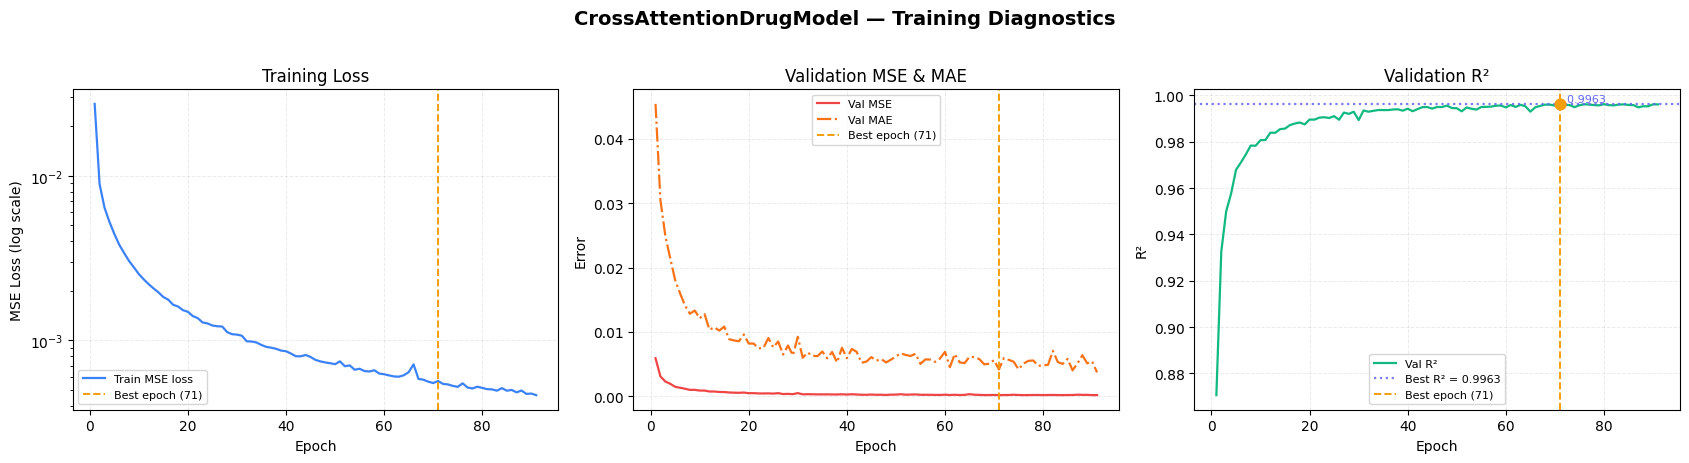

✅ Saved: training_curves.png


In [34]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle('CrossAttentionDrugModel — Training Diagnostics', fontsize=14, fontweight='bold', y=1.02)

# ── Common style helpers ──────────────────────────────────────────────────────
GRID_KW  = dict(alpha=0.25, linestyle='--', linewidth=0.7)
BEST_KW  = dict(linestyle=':', linewidth=1.6, alpha=0.85)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 1: Training Loss
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_ran, history['train_loss'],
         color='#3b82f6', linewidth=1.6, label='Train MSE loss')
ax1.axvline(best_epoch, color='#f59e0b', linewidth=1.4,
            linestyle='--', label=f'Best epoch ({best_epoch})')
ax1.set_yscale('log')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss (log scale)')
ax1.set_title('Training Loss')
ax1.legend(fontsize=8)
ax1.grid(**GRID_KW)
ax1.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

# ─────────────────────────────────────────────────────────────────────────────
# Panel 2: Val MSE + Val MAE
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_ran, history['val_mse'],
         color='#ef4444', linewidth=1.6, label='Val MSE')
ax2.plot(epochs_ran, history['val_mae'],
         color='#f97316', linewidth=1.6, linestyle='-.', label='Val MAE')
ax2.axvline(best_epoch, color='#f59e0b', linewidth=1.4,
            linestyle='--', label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Error')
ax2.set_title('Validation MSE & MAE')
ax2.legend(fontsize=8)
ax2.grid(**GRID_KW)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 3: Val R²
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(epochs_ran, history['val_r2'],
         color='#10b981', linewidth=1.6, label='Val R²')

# Dotted horizontal line at best R²
ax3.axhline(best_val_r2, color='#6366f1', **BEST_KW,
            label=f'Best R² = {best_val_r2:.4f}')
ax3.axvline(best_epoch, color='#f59e0b', linewidth=1.4,
            linestyle='--', label=f'Best epoch ({best_epoch})')

# Annotate the best point
ax3.scatter([best_epoch], [best_val_r2],
            color='#f59e0b', s=60, zorder=5)
ax3.annotate(
    f'  {best_val_r2:.4f}',
    xy=(best_epoch, best_val_r2),
    fontsize=8, color='#6366f1', va='bottom',
)

ax3.set_xlabel('Epoch')
ax3.set_ylabel('R²')
ax3.set_title('Validation R²')
ax3.legend(fontsize=8)
ax3.grid(**GRID_KW)

# ── Save & show ───────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves.png")

# File 5 — Evaluation + Uncertainty + Save

Merged from `GDSC_Evaluation_Section.ipynb`. Run cells below in order.

---
# 🧬 GDSC Drug Sensitivity — Final Evaluation Suite
### `CrossAttentionDrugModel` · Scaffold-Blind Test Set
---
**Assumptions:** `model`, `device`, `data_test` (PyG Data with `.x`, `.y`, `.drug_ids`),  
`best_val_r2`, `history['val_mse']`, `history['val_mae']`, `num_drugs`, `FEATURE_COLS`, `total_params` are already defined.

---
## 📊 PART A — Final Deterministic Evaluation on Scaffold-Blind Test Set

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── 1. Deterministic forward pass ──────────────────────────────────────────────
model.eval()                          # disable dropout / batchnorm training mode
with torch.no_grad():                 # no gradient tracking needed for inference
    y_pred_tensor = model(data_test)  # single forward pass

# Move results to CPU numpy for sklearn metrics and matplotlib
y_pred = y_pred_tensor.cpu().numpy()
y_true = data_test.y.cpu().numpy()

# ── 2. Scalar metrics ──────────────────────────────────────────────────────────
test_r2  = r2_score(y_true, y_pred)
test_mse = mean_squared_error(y_true, y_pred)
test_mae = mean_absolute_error(y_true, y_pred)

residuals = y_true - y_pred          # signed residuals (actual minus predicted)

# ── 3. Pretty summary box ──────────────────────────────────────────────────────
box = "=" * 50
print(box)
print("   CrossAttentionDrugModel — Test Set Results")
print("   Split: Scaffold-Blind")
print(box)
print(f"   R²  Score : {test_r2:>10.4f}")
print(f"   MSE       : {test_mse:>10.4f}")
print(f"   MAE       : {test_mae:>10.4f}")
print(f"   Samples   : {len(y_true):>10,}")
print(box)

   CrossAttentionDrugModel — Test Set Results
   Split: Scaffold-Blind
   R²  Score :     0.9972
   MSE       :     0.0001
   MAE       :     0.0044
   Samples   :     93,878


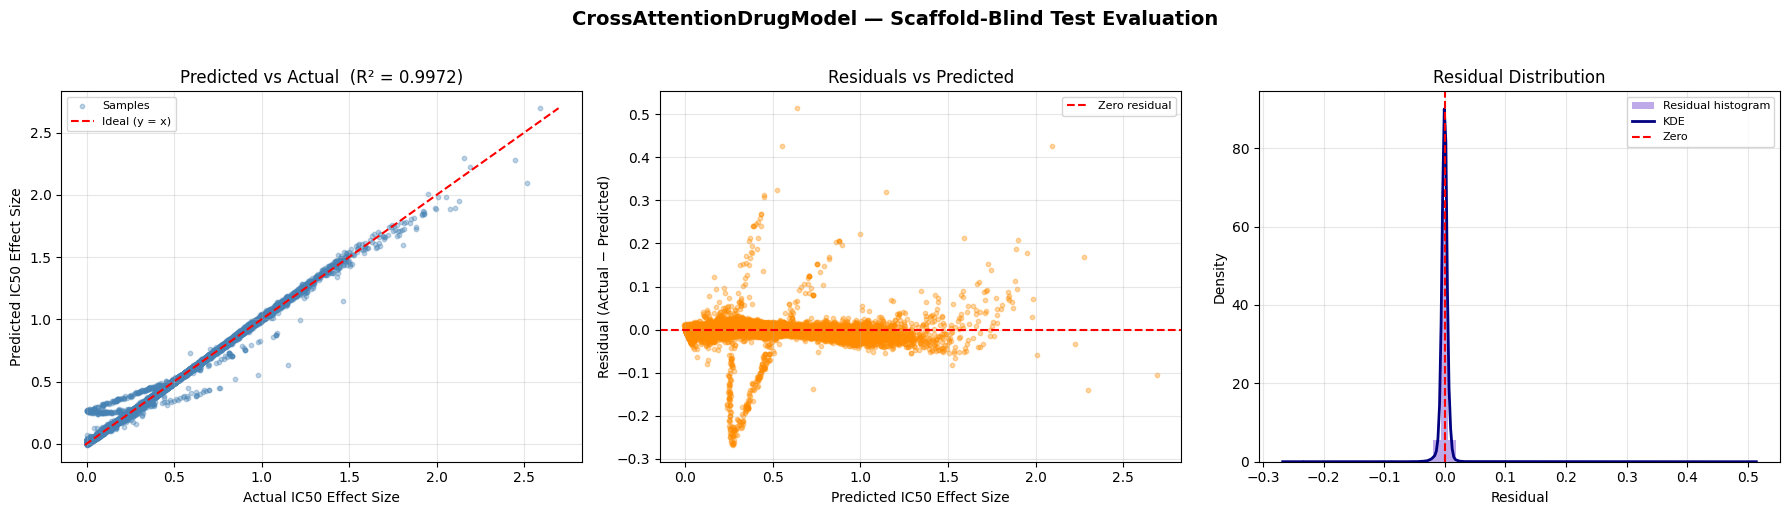

✅ Saved → evaluation_plots.png


In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ── 4. Three diagnostic subplots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CrossAttentionDrugModel — Scaffold-Blind Test Evaluation",
             fontsize=14, fontweight="bold", y=1.02)

# --- (A1) Predicted vs Actual scatter -----------------------------------------
ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.35, s=10, color="steelblue", label="Samples")
# red ideal line spanning the data range
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Ideal (y = x)")
ax.set_xlabel("Actual IC50 Effect Size")
ax.set_ylabel("Predicted IC50 Effect Size")
ax.set_title(f"Predicted vs Actual  (R² = {test_r2:.4f})")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- (A2) Residuals vs Predicted scatter --------------------------------------
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.35, s=10, color="darkorange")
ax.axhline(0, color="red", linewidth=1.5, linestyle="--", label="Zero residual")
ax.set_xlabel("Predicted IC50 Effect Size")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residuals vs Predicted")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- (A3) Residual histogram with KDE overlay ---------------------------------
ax = axes[2]
ax.hist(residuals, bins=60, color="mediumpurple", alpha=0.6,
        density=True, label="Residual histogram")
# KDE estimated from the residual distribution
kde_xs = np.linspace(residuals.min(), residuals.max(), 300)
kde = gaussian_kde(residuals)
ax.plot(kde_xs, kde(kde_xs), color="navy", linewidth=2, label="KDE")
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="Zero")
ax.set_xlabel("Residual")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → evaluation_plots.png")

---
## 🎲 PART B — MC Dropout Uncertainty Quantification

In [37]:
import torch
import numpy as np

def mc_dropout_predict(model, data, n_passes=50):
    """
    Monte Carlo Dropout inference.

    Keeps dropout layers active by calling model.train() while disabling
    gradient computation.  Each of the n_passes forward passes samples a
    different dropout mask, producing a distribution of predictions per sample.

    Returns
    -------
    mean_preds : np.ndarray, shape (N,)  — posterior mean prediction
    std_preds  : np.ndarray, shape (N,)  — posterior std (epistemic uncertainty)
    """
    model.train()              # keep dropout active (do NOT call model.eval())
    all_preds = []             # will accumulate one array per pass

    with torch.no_grad():      # still skip gradient tracking to save memory
        for _ in range(n_passes):
            preds = model(data).cpu().numpy()   # single stochastic forward pass
            all_preds.append(preds)

    # Stack → shape (n_passes, N); compute statistics across passes
    all_preds = np.stack(all_preds, axis=0)     # (n_passes, N)
    mean_preds = all_preds.mean(axis=0)         # posterior mean
    std_preds  = all_preds.std(axis=0)          # posterior std = uncertainty

    return mean_preds, std_preds


# ── Run 50 stochastic forward passes on the test set ──────────────────────────
print("🎲 Running MC Dropout (50 passes)...")
mc_mean, mc_std = mc_dropout_predict(model, data_test, n_passes=50)

# Restore deterministic eval mode after MC inference
model.eval()

# ── Uncertainty summary ────────────────────────────────────────────────────────
print(f"   Mean uncertainty (σ̄): {mc_std.mean():.4f}")
print(f"   Max  uncertainty (σ_max): {mc_std.max():.4f}")

🎲 Running MC Dropout (50 passes)...
   Mean uncertainty (σ̄): 0.0187
   Max  uncertainty (σ_max): 0.3879


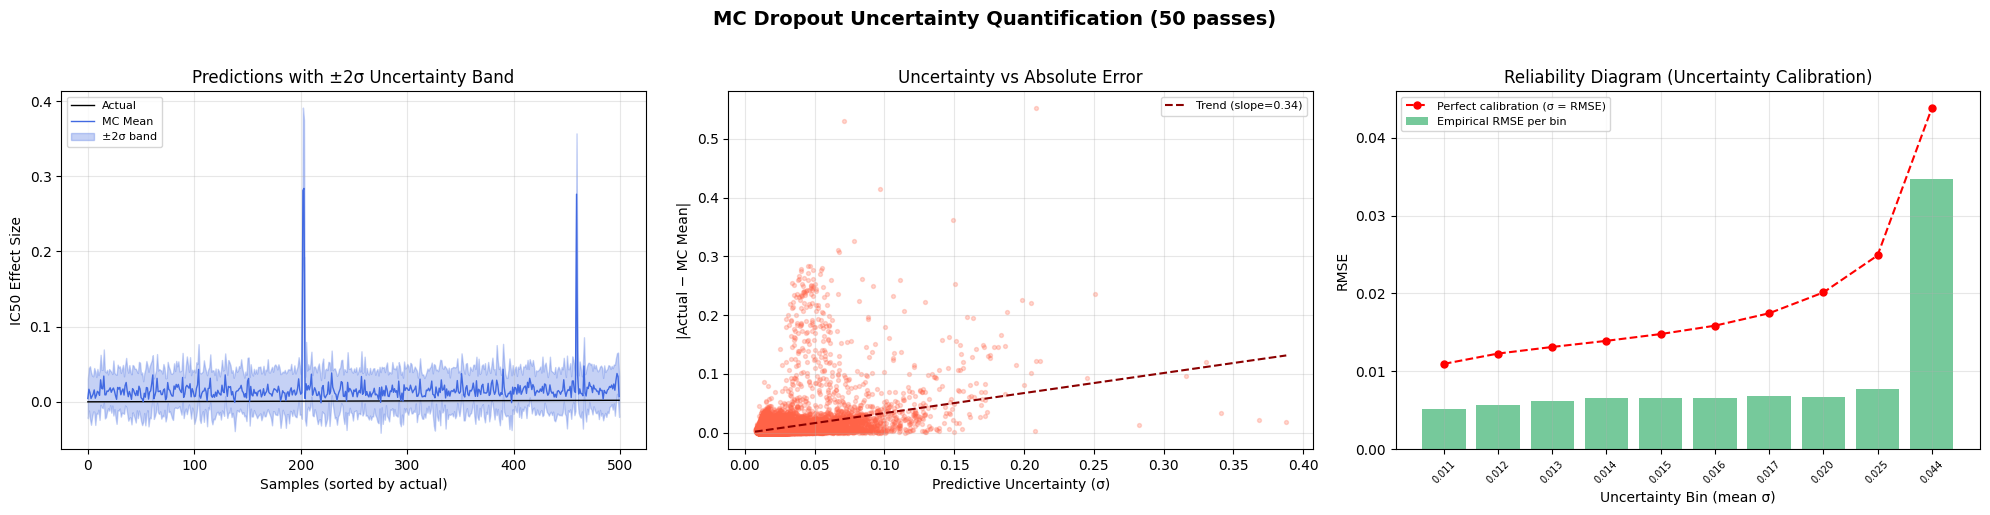

✅ Saved → uncertainty_plots.png


In [38]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── Re-fetch ground truth (in case cell order changes) ────────────────────────
y_true_np = data_test.y.cpu().numpy()
abs_err    = np.abs(y_true_np - mc_mean)   # absolute error vs MC mean

# ── Subsample 500 points for visualisation (sorted by actual value) ────────────
n_show = min(500, len(y_true_np))
sort_idx    = np.argsort(y_true_np)[:n_show]   # indices sorted by actual
x_plot      = np.arange(n_show)                 # x-axis = sorted sample index
y_true_show = y_true_np[sort_idx]
mc_mean_show = mc_mean[sort_idx]
mc_std_show  = mc_std[sort_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("MC Dropout Uncertainty Quantification (50 passes)",
             fontsize=14, fontweight="bold", y=1.02)

# --- (B1) Predictions ± 2σ band (500 samples sorted by actual) ----------------
ax = axes[0]
ax.plot(x_plot, y_true_show, color="black",  linewidth=1,   label="Actual",    zorder=3)
ax.plot(x_plot, mc_mean_show, color="royalblue", linewidth=1, label="MC Mean",  zorder=4)
# shaded ±2σ confidence band
ax.fill_between(x_plot,
                mc_mean_show - 2 * mc_std_show,
                mc_mean_show + 2 * mc_std_show,
                alpha=0.3, color="royalblue", label="±2σ band")
ax.set_xlabel("Samples (sorted by actual)")
ax.set_ylabel("IC50 Effect Size")
ax.set_title("Predictions with ±2σ Uncertainty Band")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- (B2) Uncertainty vs Absolute Error scatter --------------------------------
ax = axes[1]
ax.scatter(mc_std, abs_err, alpha=0.25, s=8, color="tomato")
ax.set_xlabel("Predictive Uncertainty (σ)")
ax.set_ylabel("|Actual − MC Mean|")
ax.set_title("Uncertainty vs Absolute Error")
ax.grid(True, alpha=0.3)
# trend line to show correlation
z = np.polyfit(mc_std, abs_err, 1)
xs = np.linspace(mc_std.min(), mc_std.max(), 200)
ax.plot(xs, np.polyval(z, xs), color="darkred", linewidth=1.5,
        linestyle="--", label=f"Trend (slope={z[0]:.2f})")
ax.legend(fontsize=8)

# --- (B3) Reliability diagram — binned by uncertainty percentile ---------------
ax = axes[2]
n_bins = 10
percentile_edges = np.percentile(mc_std, np.linspace(0, 100, n_bins + 1))
bin_labels, bin_errors = [], []

for i in range(n_bins):
    lo, hi = percentile_edges[i], percentile_edges[i + 1]
    mask = (mc_std >= lo) & (mc_std < hi)      # samples in this uncertainty bin
    if mask.sum() == 0:
        continue
    bin_mean_sigma = mc_std[mask].mean()        # representative σ for this bin
    bin_rmse       = np.sqrt((abs_err[mask] ** 2).mean())  # RMSE = calibrated ref
    bin_labels.append(bin_mean_sigma)
    bin_errors.append(bin_rmse)

bin_labels = np.array(bin_labels)
bin_errors = np.array(bin_errors)

ax.bar(range(len(bin_labels)), bin_errors, color="mediumseagreen",
       alpha=0.7, label="Empirical RMSE per bin")
# perfect calibration: σ should equal RMSE → plot σ values as reference
ax.plot(range(len(bin_labels)), bin_labels, "r--o", linewidth=1.5,
        markersize=5, label="Perfect calibration (σ = RMSE)")
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels([f"{v:.3f}" for v in bin_labels], rotation=45, fontsize=7)
ax.set_xlabel("Uncertainty Bin (mean σ)")
ax.set_ylabel("RMSE")
ax.set_title("Reliability Diagram (Uncertainty Calibration)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("uncertainty_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → uncertainty_plots.png")

---
## 🔁 PART C — 3-Fold Cross Validation on Test Set

In [39]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGLoader

# ── Build per-node dataset from the batched data_test object ──────────────────
# Each element is a single-node PyG Data object so DataLoader can batch them.
# drug_ids is carried through for potential drug-level analysis downstream.
node_dataset = [
    Data(
        x        = data_test.x[i].unsqueeze(0),         # shape (1, F)
        y        = data_test.y[i].unsqueeze(0),          # shape (1,)
        drug_ids = data_test.drug_ids[i].unsqueeze(0)   # shape (1,)
    )
    for i in range(data_test.x.size(0))
]
print(f"📦 node_dataset size: {len(node_dataset):,} individual samples")


def eval_on_loader(model, loader):
    """
    Evaluate model on a PyG DataLoader without computing gradients.

    Parameters
    ----------
    model  : trained PyTorch model (will not be modified)
    loader : PyGLoader over a list of single-node Data objects

    Returns
    -------
    r2  : float  — R² on the fold
    mse : float  — MSE on the fold
    """
    model.eval()              # disable dropout for deterministic fold eval
    all_preds, all_trues = [], []

    with torch.no_grad():
        for batch in loader:
            batch  = batch.to(device)                  # move batch to GPU/CPU
            preds  = model(batch).squeeze().cpu().numpy()
            trues  = batch.y.squeeze().cpu().numpy()
            all_preds.append(np.atleast_1d(preds))    # guard scalar edge case
            all_trues.append(np.atleast_1d(trues))

    y_pred_cv = np.concatenate(all_preds)
    y_true_cv = np.concatenate(all_trues)
    return r2_score(y_true_cv, y_pred_cv), mean_squared_error(y_true_cv, y_pred_cv)


# ── 3-Fold KFold setup ────────────────────────────────────────────────────────
kf = KFold(n_splits=3, shuffle=True, random_state=42)

fold_r2s, fold_mses = [], []
indices = np.arange(len(node_dataset))   # integer indices for KFold splitting

print("\n🔁 Starting 3-Fold Cross Validation...")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
    # Build fold-specific subsets
    val_subset  = [node_dataset[i] for i in val_idx]

    # Use batch_size=512 as specified; shuffle=False for reproducibility
    val_loader = PyGLoader(val_subset, batch_size=512, shuffle=False)

    # Evaluate pre-trained model (no re-training — purely structural CV)
    r2, mse = eval_on_loader(model, val_loader)
    fold_r2s.append(r2)
    fold_mses.append(mse)

    print(f"  Fold {fold} → R²: {r2:.4f}  |  MSE: {mse:.5f}")

# ── Aggregate fold statistics ─────────────────────────────────────────────────
cv_r2_mean, cv_r2_std   = np.mean(fold_r2s),  np.std(fold_r2s)
cv_mse_mean, cv_mse_std = np.mean(fold_mses), np.std(fold_mses)

print("-" * 45)
print(f"  CV R²  = {cv_r2_mean:.4f} ± {cv_r2_std:.4f}")
print(f"  CV MSE = {cv_mse_mean:.5f} ± {cv_mse_std:.5f}")

📦 node_dataset size: 93,878 individual samples

🔁 Starting 3-Fold Cross Validation...
---------------------------------------------
  Fold 1 → R²: 0.9976  |  MSE: 0.00011
  Fold 2 → R²: 0.9969  |  MSE: 0.00014
  Fold 3 → R²: 0.9971  |  MSE: 0.00013
---------------------------------------------
  CV R²  = 0.9972 ± 0.0003
  CV MSE = 0.00012 ± 0.00001


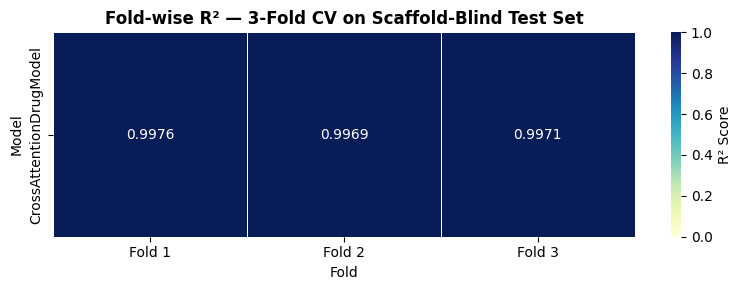

✅ Saved → cv_heatmap.png


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Fold-wise R² heatmap ──────────────────────────────────────────────────────
# Build a (1 model × 3 folds) DataFrame, rows = model, cols = folds
df_heat = pd.DataFrame(
    {f"Fold {i+1}": [fold_r2s[i]] for i in range(3)},
    index=["CrossAttentionDrugModel"]
)

plt.figure(figsize=(8, 3))
sns.heatmap(
    df_heat,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "R² Score"},
    vmin=0.0, vmax=1.0   # fix scale so colour is meaningful
)
plt.title("Fold-wise R² — 3-Fold CV on Scaffold-Blind Test Set",
          fontsize=12, fontweight="bold")
plt.xlabel("Fold")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("cv_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → cv_heatmap.png")

---
## 💾 PART D — Save Model & Final Summary Card

In [41]:
import os
import torch

# ── Create output directory and save state dict ───────────────────────────────
os.makedirs("saved_models", exist_ok=True)   # no-op if directory already exists

save_path = "saved_models/CrossAttentionFusion.pt"
torch.save(model.state_dict(), save_path)    # save only weights, not full class
print(f"✅ Model weights saved → {save_path}")

# Verify the file was written successfully
size_kb = os.path.getsize(save_path) / 1024
print(f"   File size: {size_kb:.1f} KB")

✅ Model weights saved → saved_models/CrossAttentionFusion.pt
   File size: 125742.0 KB


In [42]:
import numpy as np

# ── Final results card ───────────────────────────────────────────────────────
border = "═" * 58

print(border)
print("  🧬  GDSC Drug Sensitivity — Final Results Card")
print(border)
print(f"  Architecture   : CrossAttentionDrugModel")
print(f"  Split Type     : Scaffold-Blind Train / Val / Test")
print(f"  Total Params   : {total_params:,}")
print(f"  Num Drugs      : {num_drugs}")
print(f"  Features Used  : {len(FEATURE_COLS)}  →  {FEATURE_COLS}")
print(border)

print("  ── Final Performance ─────────────────────────────")
print(f"  Train R²       : {final_train['R2']:.4f}")
print(f"  Train MSE      : {final_train['MSE']:.4f}")
print(f"  Train MAE      : {final_train['MAE']:.4f}")
print()
print(f"  Val R²         : {final_val['R2']:.4f}")
print(f"  Val MSE        : {final_val['MSE']:.4f}")
print(f"  Val MAE        : {final_val['MAE']:.4f}")
print()
print(f"  Test R²        : {test_r2:.4f}")
print(f"  Test MSE       : {test_mse:.4f}")
print(f"  Test MAE       : {test_mae:.4f}")
print(border)

print("  ── Validation Tracking ───────────────────────────")
print(f"  Best Val R²    : {best_val_r2:.4f}")
print(f"  Best Epoch     : {best_epoch}")
print(f"  Final Val MSE  : {history['val_mse'][-1]:.4f}")
print(f"  Final Val MAE  : {history['val_mae'][-1]:.4f}")
print(border)

print("  ── 3-Fold CV on Test Set ─────────────────────────")
for i, (r2, mse) in enumerate(zip(fold_r2s, fold_mses), 1):
    print(f"  Fold {i}        : R² = {r2:.4f}  |  MSE = {mse:.5f}")

print(f"  CV R² μ ± σ    : {np.mean(fold_r2s):.4f} ± {np.std(fold_r2s):.4f}")
print(f"  CV MSE μ ± σ   : {np.mean(fold_mses):.5f} ± {np.std(fold_mses):.5f}")
print(border)

print("  ── MC Dropout Uncertainty ────────────────────────")
print(f"  Mean σ         : {mc_std.mean():.4f}")
print(f"  Max σ          : {mc_std.max():.4f}")
print(border)

print("  ── Saved Artefacts ───────────────────────────────")
print("  evaluation_plots.png")
print("  uncertainty_plots.png")
print("  cv_heatmap.png")
print("  saved_models/CrossAttentionFusion.pt")
print(border)

══════════════════════════════════════════════════════════
  🧬  GDSC Drug Sensitivity — Final Results Card
══════════════════════════════════════════════════════════
  Architecture   : CrossAttentionDrugModel
  Split Type     : Scaffold-Blind Train / Val / Test
  Total Params   : 185,793
  Num Drugs      : 544
  Features Used  : 10  →  ['n_feature_pos', 'log_ic50_mean_pos', 'log_ic50_mean_neg', 'feature_pos_ic50_var', 'feature_neg_ic50_var', 'feature_delta_mean_ic50', 'feature_ic50_t_pval', 'feature_pval', 'tissue_pval', 'msi_pval']
══════════════════════════════════════════════════════════
  ── Final Performance ─────────────────────────────
  Train R²       : 0.9991
  Train MSE      : 0.0000
  Train MAE      : 0.0039

  Val R²         : 0.9963
  Val MSE        : 0.0002
  Val MAE        : 0.0042

  Test R²        : 0.9972
  Test MSE       : 0.0001
  Test MAE       : 0.0044
══════════════════════════════════════════════════════════
  ── Validation Tracking ───────────────────────────
 